**Step 1 - Environment Setup**

In [1]:
pip install transformers torch sentencepiece

In [2]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GPU available: True
Device: Tesla T4


**Step 2 - Load Handoff File**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_pickle('/content/drive/MyDrive/Community Project/Dataset/cleaned_transcripts_final.pkl')

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"Null transcripts: {df['transcript_clean'].isna().sum()}")

Mounted at /content/drive
Rows: 14738
Columns: ['ticker', 'earnings_date', 'q', 'earnings_date_is_approx', 'transcript', 'transcript_clean', 'speaker_parse_success', 'return_5d', 'return_10d', 'return_20d', 'label_5d', 'label_10d', 'label_20d']
Null transcripts: 0


**Step 3 - Handle FinBERT's 512-Token Limit**

In [4]:
from transformers import AutoTokenizer
import pandas as pd
import numpy as np

# ── Load FinBERT tokenizer ────────────────────────────────────────────────────
MODEL_NAME = 'ProsusAI/finbert'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Helper: count tokens in a text ───────────────────────────────────────────
def count_tokens(text):
    """Count how many tokens a text string uses."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0
    return len(tokenizer.encode(text, add_special_tokens=True))

# ── Check token lengths across the dataset ───────────────────────────────────
print("Checking token lengths across dataset...")
df = pd.read_pickle('/content/drive/MyDrive/Community Project/Dataset/cleaned_transcripts_final.pkl')
df['transcript_clean'] = df['transcript_clean'].fillna('')

sample = df['transcript_clean'].sample(min(500, len(df)), random_state=42)
token_counts = sample.apply(count_tokens)

print(f"\nToken length statistics (sample of 500):")
print(f"  Mean:   {token_counts.mean():.0f} tokens")
print(f"  Median: {token_counts.median():.0f} tokens")
print(f"  Max:    {token_counts.max():.0f} tokens")
print(f"  Min:    {token_counts.min():.0f} tokens")
print(f"\nTranscripts exceeding 512 tokens: {(token_counts > 512).sum()} / {len(token_counts)}")
print(f"Transcripts within 512 tokens:   {(token_counts <= 512).sum()} / {len(token_counts)}")

# ── Chunker: split transcript into overlapping 512-token windows ──────────────
def chunk_text(text, max_tokens=512, overlap=50):
    """
    Split a long text into overlapping chunks of max_tokens each.
    Uses the tokenizer to ensure accurate token boundaries.
    Returns a list of decoded text chunks.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []

    # Tokenize the full text (no special tokens yet)
    tokens = tokenizer.encode(text, add_special_tokens=False)

    if len(tokens) == 0:
        return []

    # If short enough, return as single chunk
    # Reserve 2 tokens for [CLS] and [SEP]
    effective_max = max_tokens - 2
    if len(tokens) <= effective_max:
        return [text]

    # Split into overlapping windows to preserve meanings
    chunks = []
    start  = 0
    while start < len(tokens):
        end        = min(start + effective_max, len(tokens))
        chunk_ids  = tokens[start:end]
        chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)
        chunks.append(chunk_text)

        if end == len(tokens):
            break
        start = end - overlap  # overlap with next chunk

    return chunks

# ── Test chunker on a sample transcript ──────────────────────────────────────
sample_text = df['transcript_clean'].iloc[0]
sample_chunks = chunk_text(sample_text)

print(f"\nChunker test:")
print(f"  Original text length:  {len(sample_text)} characters")
print(f"  Original token count:  {count_tokens(sample_text)} tokens")
print(f"  Number of chunks:      {len(sample_chunks)}")

for i, chunk in enumerate(sample_chunks[:3]):
    print(f"  Chunk {i+1} ({count_tokens(chunk)} tokens): {chunk[:100]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Checking token lengths across dataset...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (23292 > 512). Running this sequence through the model will result in indexing errors



Token length statistics (sample of 500):
  Mean:   7507 tokens
  Median: 8932 tokens
  Max:    23292 tokens
  Min:    5 tokens

Transcripts exceeding 512 tokens: 358 / 500
Transcripts within 512 tokens:   142 / 500

Chunker test:
  Original text length:  35390 characters
  Original token count:  7270 tokens
  Number of chunks:      16
  Chunk 1 (512 tokens): prepared remarks : at this time, i would like to turn the conference over to juliet yang, senior dir...
  Chunk 2 (512 tokens): , we are reaching a much broader audience. for the second quarter, maus were 172 million, up 55 % an...
  Chunk 3 (512 tokens): hou lang, ru hai, xi xiang feng trilogy videos, which all have been widely successful, and we are se...


**Step 4 - Build the FinBERT Scoring Pipeline**

In [5]:
from transformers import AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import os
import time

os.makedirs('Outputs/sentiment_extraction', exist_ok=True)
CHECKPOINT_FILE = 'Outputs/sentiment_extraction/sentiment_scores_raw.csv'

# ── Load FinBERT model ────────────────────────────────────────────────────────
print("Loading FinBERT model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

# ── Read label order from model config ────────────────────────────────────────
ID2LABEL = {i: label.lower() for i, label in model.config.id2label.items()}
print(f"FinBERT label map (from model config): {ID2LABEL}")
print("Model loaded successfully.\n")

Loading FinBERT model...
Using device: cuda


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT label map (from model config): {0: 'positive', 1: 'negative', 2: 'neutral'}
Model loaded successfully.



In [6]:
# ── Core scorer: score a single chunk of text ─────────────────────────────────
def score_chunk(text):
    """
    Run FinBERT on a single text chunk (must be ≤ 512 tokens).
    Returns dict with positive, negative, neutral probabilities.
    Uses model.config.id2label to avoid hardcoding label order.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs   = F.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

    # Use ID2LABEL to map probabilities
    prob_dict = {ID2LABEL[i]: float(probs[i]) for i in range(len(probs))}

    return {
        'positive': prob_dict.get('positive', 0.0),
        'negative': prob_dict.get('negative', 0.0),
        'neutral':  prob_dict.get('neutral',  0.0)
    }

# ── Document scorer: score a full transcript via chunking ─────────────────────
def score_transcript(text, max_tokens=512, overlap=50):
    """
    Score a full transcript by chunking and mean-aggregating FinBERT scores.
    Returns positive_ratio, negative_ratio, neutral_ratio,
    net_sentiment, sentiment_volatility, n_chunks.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'positive_ratio':       np.nan,
            'negative_ratio':       np.nan,
            'neutral_ratio':        np.nan,
            'net_sentiment':        np.nan,
            'sentiment_volatility': np.nan,
            'n_chunks':             0
        }

    chunks = chunk_text(text, max_tokens=max_tokens, overlap=overlap)

    if len(chunks) == 0:
        return {
            'positive_ratio':       np.nan,
            'negative_ratio':       np.nan,
            'neutral_ratio':        np.nan,
            'net_sentiment':        np.nan,
            'sentiment_volatility': np.nan,
            'n_chunks':             0
        }

    chunk_scores = [score_chunk(c) for c in chunks]

    pos_scores = [s['positive'] for s in chunk_scores]
    neg_scores = [s['negative'] for s in chunk_scores]
    neu_scores = [s['neutral']  for s in chunk_scores]
    net_scores = [p - n for p, n in zip(pos_scores, neg_scores)]

    return {
        'positive_ratio':       float(np.mean(pos_scores)),
        'negative_ratio':       float(np.mean(neg_scores)),
        'neutral_ratio':        float(np.mean(neu_scores)),
        'net_sentiment':        float(np.mean(net_scores)),
        'sentiment_volatility': float(np.std(net_scores)) if len(net_scores) > 1 else 0.0,
        'n_chunks':             len(chunks)
    }

In [7]:
# ── Test scorer on a single transcript ───────────────────────────────────────
print("Testing scorer on a single transcript...")
test_text   = df['transcript_clean'].iloc[0]
test_ticker = df['ticker'].iloc[0]
test_result = score_transcript(test_text)

print(f"\nTest result for ticker: {test_ticker}")
print(f"  Positive ratio:       {test_result['positive_ratio']:.4f}")
print(f"  Negative ratio:       {test_result['negative_ratio']:.4f}")
print(f"  Neutral ratio:        {test_result['neutral_ratio']:.4f}")
print(f"  Net sentiment:        {test_result['net_sentiment']:.4f}")
print(f"  Sentiment volatility: {test_result['sentiment_volatility']:.4f}")
print(f"  Chunks processed:     {test_result['n_chunks']}")

Testing scorer on a single transcript...

Test result for ticker: BILI
  Positive ratio:       0.6076
  Negative ratio:       0.0137
  Neutral ratio:        0.3787
  Net sentiment:        0.5939
  Sentiment volatility: 0.3129
  Chunks processed:     16


In [8]:
# ── Run FinBERT on all 14,738 transcripts ─────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

LOCAL_CHECKPOINT = 'Outputs/sentiment_extraction/sentiment_scores_raw.csv'
DRIVE_CHECKPOINT = '/content/drive/MyDrive/Community Project/Dataset/sentiment_scores_raw.csv'
CHECKPOINT_EVERY = 500

os.makedirs('Outputs/sentiment_extraction', exist_ok=True)

# Load checkpoint from Drive if local doesn't exist
if os.path.exists(LOCAL_CHECKPOINT):
    checkpoint_df  = pd.read_csv(LOCAL_CHECKPOINT)
    completed_idxs = set(checkpoint_df['original_idx'].tolist())
    print(f"Resuming from local: {len(completed_idxs)} rows done")
elif os.path.exists(DRIVE_CHECKPOINT):
    checkpoint_df  = pd.read_csv(DRIVE_CHECKPOINT)
    completed_idxs = set(checkpoint_df['original_idx'].tolist())
    checkpoint_df.to_csv(LOCAL_CHECKPOINT, index=False)
    print(f"Resuming from Drive: {len(completed_idxs)} rows done")
else:
    checkpoint_df  = pd.DataFrame()
    completed_idxs = set()
    print("No checkpoint found — starting from scratch")

results            = []
start_time         = time.time()
total              = len(df)
processed_this_run = 0

print(f"\nScoring {total} transcripts with FinBERT...")
print(f"Device: {device}\n")

for i, (idx, row) in enumerate(df.iterrows()):

    if idx in completed_idxs:
        continue

    text = row['transcript_clean']

    try:
        scores = score_transcript(text)
    except Exception as e:
        scores = {
            'positive_ratio':       np.nan,
            'negative_ratio':       np.nan,
            'neutral_ratio':        np.nan,
            'net_sentiment':        np.nan,
            'sentiment_volatility': np.nan,
            'n_chunks':             0
        }

    scores['original_idx']  = idx
    scores['ticker']        = row['ticker']
    scores['earnings_date'] = row['earnings_date']
    scores['q']             = row['q']
    results.append(scores)

    processed_this_run += 1

    # Progress update using processed_this_run for accurate ETA
    if processed_this_run % 100 == 0 and processed_this_run > 0:
        elapsed        = time.time() - start_time
        rate           = processed_this_run / elapsed
        remaining_rows = total - len(completed_idxs) - processed_this_run
        remaining      = max(0, remaining_rows) / rate / 60

        print(f"  Processed this run: {processed_this_run} | "
              f"Total completed: {len(completed_idxs) + processed_this_run}/{total} | "
              f"Elapsed: {elapsed/60:.1f}m | "
              f"Rate: {rate:.2f} rows/s | "
              f"ETA: {remaining:.1f}m")

    # Save checkpoint to both local and Drive every 500 rows
    if len(results) % CHECKPOINT_EVERY == 0:
        batch_df      = pd.DataFrame(results)
        checkpoint_df = pd.concat([checkpoint_df, batch_df], ignore_index=True)

        checkpoint_df.to_csv(LOCAL_CHECKPOINT, index=False)  # local
        checkpoint_df.to_csv(DRIVE_CHECKPOINT, index=False)  # Drive backup

        completed_idxs.update(batch_df['original_idx'].tolist())
        results = []
        print(f"  ✓ Checkpoint saved locally and to Drive: {len(checkpoint_df)} rows total")

# Save any remaining results
if results:
    batch_df      = pd.DataFrame(results)
    checkpoint_df = pd.concat([checkpoint_df, batch_df], ignore_index=True)
    checkpoint_df.to_csv(LOCAL_CHECKPOINT, index=False)
    checkpoint_df.to_csv(DRIVE_CHECKPOINT, index=False)
    completed_idxs.update(batch_df['original_idx'].tolist())

print(f"\nFinBERT scoring complete.")
print(f"  Total rows scored: {len(checkpoint_df)}")
print(f"  Total time:        {(time.time() - start_time)/60:.1f} minutes")
print(f"  Saved locally:     {LOCAL_CHECKPOINT}")
print(f"  Saved to Drive:    {DRIVE_CHECKPOINT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
No checkpoint found — starting from scratch

Scoring 14738 transcripts with FinBERT...
Device: cuda

  Processed this run: 100 | Total completed: 100/14738 | Elapsed: 1.0m | Rate: 1.74 rows/s | ETA: 140.3m
  Processed this run: 200 | Total completed: 200/14738 | Elapsed: 2.1m | Rate: 1.56 rows/s | ETA: 155.1m
  Processed this run: 300 | Total completed: 300/14738 | Elapsed: 3.1m | Rate: 1.59 rows/s | ETA: 151.2m
  Processed this run: 400 | Total completed: 400/14738 | Elapsed: 4.2m | Rate: 1.58 rows/s | ETA: 151.6m
  Processed this run: 500 | Total completed: 500/14738 | Elapsed: 5.3m | Rate: 1.58 rows/s | ETA: 149.8m
  ✓ Checkpoint saved locally and to Drive: 500 rows total
  Processed this run: 600 | Total completed: 1100/14738 | Elapsed: 6.3m | Rate: 1.59 rows/s | ETA: 142.8m
  Processed this run: 700 | Total completed: 1200/14738 | Elapsed: 7.2m | Rate: 1

In [9]:
# ── Dedup checkpoint after scoring ───────────────────────────────────────────
LOCAL_CHECKPOINT = 'Outputs/sentiment_extraction/sentiment_scores_raw.csv'
DRIVE_CHECKPOINT = '/content/drive/MyDrive/Community Project/Dataset/sentiment_scores_raw.csv'

checkpoint_df = pd.read_csv(LOCAL_CHECKPOINT)
print(f"Raw checkpoint rows: {len(checkpoint_df)}")

# Remove duplicates
checkpoint_df = checkpoint_df.drop_duplicates(subset=['original_idx'], keep='last')
print(f"After dedup: {len(checkpoint_df)} rows")

# Save clean version to both locations
checkpoint_df.to_csv(LOCAL_CHECKPOINT, index=False)
checkpoint_df.to_csv(DRIVE_CHECKPOINT, index=False)
print(f"Saved clean checkpoint locally and to Drive")
print(f"Drive path: {DRIVE_CHECKPOINT}")

Raw checkpoint rows: 14738
After dedup: 14738 rows
Saved clean checkpoint locally and to Drive
Drive path: /content/drive/MyDrive/Community Project/Dataset/sentiment_scores_raw.csv


**Step 5 - Aggregate to Call-Level Features**

In [2]:
import pandas as pd
import numpy as np
import os

# ── Load raw FinBERT scores from checkpoint ───────────────────────────────────
print("Loading raw FinBERT scores...")
scores_raw = pd.read_csv('Outputs/sentiment_extraction/sentiment_scores_raw.csv')

print(f"Raw scores shape: {scores_raw.shape}")
print(f"Columns: {scores_raw.columns.tolist()}")
print(f"Sample:\n{scores_raw.head(3).to_string()}")

# ── Check coverage ────────────────────────────────────────────────────────────
total_transcripts = len(scores_raw)
scored            = scores_raw['net_sentiment'].notna().sum()
coverage          = scored / total_transcripts * 100

print(f"\nCoverage:")
print(f"  Total transcripts:   {total_transcripts}")
print(f"  Successfully scored: {scored}")
print(f"  Coverage rate:       {coverage:.1f}%")

Loading raw FinBERT scores...
Raw scores shape: (14738, 10)
Columns: ['positive_ratio', 'negative_ratio', 'neutral_ratio', 'net_sentiment', 'sentiment_volatility', 'n_chunks', 'original_idx', 'ticker', 'earnings_date', 'q']
Sample:
   positive_ratio  negative_ratio  neutral_ratio  net_sentiment  sentiment_volatility  n_chunks  original_idx ticker earnings_date        q
0        0.607586        0.013696       0.378718       0.593890              0.312909        16             0   BILI    2020-08-27  2020-Q2
1        0.477832        0.143188       0.378980       0.334645              0.331315        14             1    GFF    2020-07-30  2020-Q3
2        0.154201        0.011048       0.834752       0.143153              0.000000         1             2   LRCX    2019-10-23  2020-Q1

Coverage:
  Total transcripts:   14738
  Successfully scored: 14738
  Coverage rate:       100.0%


In [3]:
# ── Aggregate to call-level features ─────────────────────────────────────────
# Each row in scores_raw already represents one transcript (one earnings call)
# Aggregation was done inside score_transcript() via mean across chunks
# Only clean, validate, and compute derived ratios here

print("Aggregating to call-level features...")

call_level = scores_raw.copy()

# Verify ratios sum to ~1.0 (sanity check)
call_level['ratio_sum'] = (
    call_level['positive_ratio'] +
    call_level['negative_ratio'] +
    call_level['neutral_ratio']
)

ratio_check = call_level['ratio_sum'].dropna()
print(f"\nRatio sum check (should be ~1.0):")
print(f"  Mean:  {ratio_check.mean():.4f}")
print(f"  Min:   {ratio_check.min():.4f}")
print(f"  Max:   {ratio_check.max():.4f}")
print(f"  Rows deviating > 0.01 from 1.0: "
      f"{((ratio_check - 1.0).abs() > 0.01).sum()}")

# Drop the check column
call_level = call_level.drop(columns=['ratio_sum'])

# ── Calculate net sentiment ────────────────────────────────────────────────────
call_level['net_sentiment'] = (
    call_level['positive_ratio'] - call_level['negative_ratio']
)

print(f"\nNet sentiment distribution:")
print(call_level['net_sentiment'].describe())
print(f"\nCall-level features shape: {call_level.shape}")
print(f"\nSample output:")
print(call_level[['ticker', 'earnings_date', 'q',
                   'positive_ratio', 'negative_ratio', 'neutral_ratio',
                   'net_sentiment', 'sentiment_volatility',
                   'n_chunks']].head(5).to_string())

Aggregating to call-level features...

Ratio sum check (should be ~1.0):
  Mean:  1.0000
  Min:   1.0000
  Max:   1.0000
  Rows deviating > 0.01 from 1.0: 0

Net sentiment distribution:
count    14738.000000
mean         0.195223
std          0.167540
min         -0.652535
25%          0.047815
50%          0.187842
75%          0.318650
max          0.940493
Name: net_sentiment, dtype: float64

Call-level features shape: (14738, 10)

Sample output:
  ticker earnings_date        q  positive_ratio  negative_ratio  neutral_ratio  net_sentiment  sentiment_volatility  n_chunks
0   BILI    2020-08-27  2020-Q2        0.607586        0.013696       0.378718       0.593890              0.312909        16
1    GFF    2020-07-30  2020-Q3        0.477832        0.143188       0.378980       0.334645              0.331315        14
2   LRCX    2019-10-23  2020-Q1        0.154201        0.011048       0.834752       0.143153              0.000000         1
3   BBSI    2019-11-06  2019-Q3        0.0

Loaded df: 14738 rows
Loaded scores_raw: 14738 rows
Merging call-level features with original dataframe...
Rows after merge: 14738
Columns: ['ticker', 'earnings_date', 'q', 'earnings_date_is_approx', 'transcript', 'transcript_clean', 'speaker_parse_success', 'return_5d', 'return_10d', 'return_20d', 'label_5d', 'label_10d', 'label_20d', 'positive_ratio', 'negative_ratio', 'neutral_ratio', 'net_sentiment', 'sentiment_volatility', 'n_chunks']


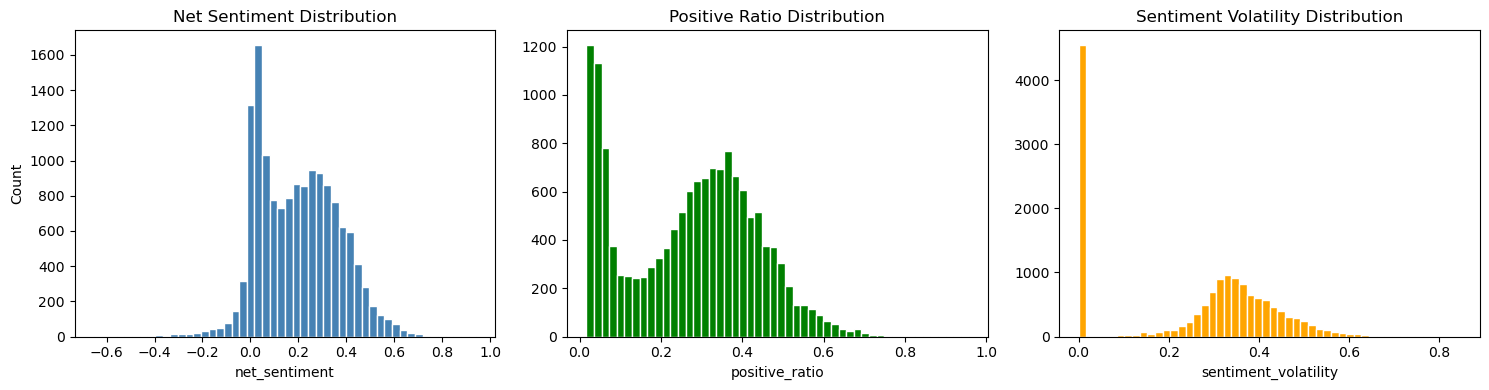

Saved: step5_sentiment_distributions.png


In [5]:
import pandas as pd
import numpy as np
import os

# ── Reload data files ─────────────────────────────────────────────────────────
df = pd.read_pickle('Data/cleaned_transcripts_final.pkl')
df['transcript_clean'] = df['transcript_clean'].fillna('')
print(f"Loaded df: {len(df)} rows")

# ── Reload raw FinBERT scores ─────────────────────────────────────────────────
scores_raw = pd.read_csv('Outputs/sentiment_extraction/sentiment_scores_raw.csv')
print(f"Loaded scores_raw: {len(scores_raw)} rows")

# ── Merge with original dataframe to bring back labels and returns ─────────────
print("Merging call-level features with original dataframe...")

df_reset = df.reset_index().rename(columns={'index': 'original_idx'})
df_merged = df_reset.merge(
    call_level[[
        'original_idx', 'positive_ratio', 'negative_ratio',
        'neutral_ratio', 'net_sentiment', 'sentiment_volatility', 'n_chunks'
    ]],
    on='original_idx',
    how='inner'
).drop(columns=['original_idx'])

print(f"Rows after merge: {len(df_merged)}")
print(f"Columns: {df_merged.columns.tolist()}")

# ── Distribution plots ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_merged['net_sentiment'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Net Sentiment Distribution')
axes[0].set_xlabel('net_sentiment')
axes[0].set_ylabel('Count')

axes[1].hist(df_merged['positive_ratio'].dropna(), bins=50, color='green', edgecolor='white')
axes[1].set_title('Positive Ratio Distribution')
axes[1].set_xlabel('positive_ratio')

axes[2].hist(df_merged['sentiment_volatility'].dropna(), bins=50, color='orange', edgecolor='white')
axes[2].set_title('Sentiment Volatility Distribution')
axes[2].set_xlabel('sentiment_volatility')

plt.tight_layout()
os.makedirs('Outputs/sentiment_extraction/validation', exist_ok=True)
plt.savefig('Outputs/sentiment_extraction/validation/step5_sentiment_distributions.png', dpi=150)
plt.show()
print("Saved: step5_sentiment_distributions.png")

**Step 6 - Extract Management vs Q&A Sentiment Separately**

In [6]:
CHECKPOINT_EVERY = 500

# ── Check exec_text and analyst_text availability ─────────────────────────────
print("Checking speaker-separated text availability...")
for col in ['exec_text', 'analyst_text', 'speaker_parse_success']:
    if col in df_merged.columns:
        non_null = df_merged[col].notna().sum()
        non_empty = df_merged[col].apply(
            lambda x: isinstance(x, str) and len(x.strip()) > 0
        ).sum()
        print(f"  {col}: {non_null} non-null, {non_empty} non-empty")
    else:
        print(f"  {col}: COLUMN MISSING")

Checking speaker-separated text availability...
  exec_text: COLUMN MISSING
  analyst_text: COLUMN MISSING
  speaker_parse_success: 14738 non-null, 0 non-empty


The speaker-tag parser developed in Phase 1 was built and validated on the ramssvimala dataset, which uses an explicit tagging convention (e.g., `KKevin MoranVice President[speech]`) to identify speakers. The Motley Fool pkl transcripts use a different formatting convention, which is why the parser produced a 0% parse rate on that corpus and `exec_text` and `analyst_text` ended up empty for all 14,738 rows. Before writing a new parser, we inspect the actual structure of the Motley Fool transcripts, specifically how speaker names, roles, and speech boundaries are delimited, so that the new parser can correctly separate management prepared remarks from analyst Q&A. Without this inspection, any parser we write would be guessing at the format and could silently produce incorrect splits, which is worse than having no split at all since it would corrupt the sentiment features rather than simply leaving them as NaN.

In [11]:
# ── Check actual Motley Fool transcript format ────────────────────────────────
sample = df['transcript'].iloc[0]
print("First 2000 characters of raw transcript:")
print(sample[:2000])
print("\nCharacters 2000-5000 of raw transcript:")
print(sample[2000:5000])
print("\n" + "="*60)
print("\nFirst 2000 characters of cleaned transcript:")
print(df['transcript_clean'].iloc[0][:2000])

First 2000 characters of raw transcript:
Prepared Remarks: Operator Good day, and welcome to the Bilibili 2020 Second Quarter Earnings Conference Call. Today's conference is being recorded. At this time, I would like to turn the conference over to Juliet Yang, Senior Director of Investor Relations. Please go ahead. Juliet Yang -- Senior Director of Investor Relations Thank you, operator. Please note the discussion today will contain forward-looking statements relating to the Company's future performance, and are intended to qualify for the Safe Harbor from liability, as established by the US Private Securities Litigation Reform Act. Such statements are not guarantees of future performance and are subject to certain risks and uncertainties, assumptions and other factors. Some of these risks are beyond the Company's control and could cause actual results to differ materially from those mentioned in today's press release and this discussion. A general discussion of the risk factors that c

In [12]:
import re

def parse_motley_fool_transcript(transcript):
    """
    Parse Motley Fool transcript format.
    Speaker pattern: 'First Last -- Title speech text...'
    Sections: 'Prepared Remarks:' and 'Questions and Answers:'
    """
    if not isinstance(transcript, str) or len(transcript.strip()) == 0:
        return '', ''

    # ── Split into Prepared Remarks and Q&A sections ──────────────────────────
    qa_markers = [
        'Questions and Answers',
        'Question-and-Answer',
        'Q&A Session',
        'QUESTION AND ANSWER',
        'Questions & Answers'
    ]

    qa_start = None
    for marker in qa_markers:
        idx = transcript.find(marker)
        if idx != -1:
            qa_start = idx
            break

    if qa_start is not None:
        prepared_section = transcript[:qa_start]
        qa_section       = transcript[qa_start:]
    else:
        prepared_section = transcript
        qa_section       = ''

    # ── Speaker pattern: "Firstname Lastname -- Title" ────────────────────────
    # Matches names like "Xin Fan -- Chief Financial Officer" or "John Smith-Jones -- Senior Vice President"
    speaker_pattern = re.compile(
        r'([A-Z][a-z]+(?:\s+[A-Z][a-z\-]+)+)\s+--\s+([^\n\.]{5,80}?)(?=\s+[A-Z]|\s*$)',
    )

    # Known analyst indicators
    analyst_indicators = [
        'analyst', 'research', 'securities', 'capital', 'partners',
        'llc', 'inc', 'group', 'investments', 'bank', 'morgan',
        'goldman', 'jpmorgan', 'barclays', 'citi', 'ubs', 'wells fargo',
        'raymond james', 'cowen', 'piper', 'stifel', 'jefferies',
        'oppenheimer', 'needham', 'canaccord', 'macquarie'
    ]

    # Known executive indicators
    exec_indicators = [
        'chief', 'ceo', 'cfo', 'coo', 'cto', 'president', 'director',
        'officer', 'founder', 'chairman', 'vice president', 'vp',
        'head of', 'senior vice', 'executive vice', 'managing director',
        'investor relations', 'controller', 'treasurer', 'secretary'
    ]

    def classify_speaker(title):
        title_lower = title.lower()
        # Operator is always excluded
        if 'operator' in title_lower:
            return 'operator'
        exec_score    = sum(1 for kw in exec_indicators    if kw in title_lower)
        analyst_score = sum(1 for kw in analyst_indicators if kw in title_lower)
        if exec_score > 0 and exec_score >= analyst_score:
            return 'exec'
        if analyst_score > 0:
            return 'analyst'
        # Default: in prepared remarks = exec, in Q&A = analyst
        return 'unknown'

    def extract_blocks(text, default_type):
        """
        Find all speaker tags and extract the text between them.
        Returns list of (speaker_type, speech_text) tuples.
        """
        # Find all speaker positions
        matches = list(speaker_pattern.finditer(text))

        if not matches:
            # No speakers found — return whole text as default type
            return [(default_type, text.strip())]

        blocks   = []
        for i, match in enumerate(matches):
            name  = match.group(1).strip()
            title = match.group(2).strip()
            spk_type = classify_speaker(title)
            if spk_type == 'unknown':
                spk_type = default_type

            # Speech starts right after the speaker tag
            speech_start = match.end()
            speech_end   = matches[i+1].start() if i+1 < len(matches) else len(text)
            speech       = text[speech_start:speech_end].strip()

            if speech and spk_type != 'operator':
                blocks.append((spk_type, speech))

        return blocks

    # ── Extract blocks ────────────────────────────────────────────────────────
    prepared_blocks = extract_blocks(prepared_section, 'exec')
    qa_blocks       = extract_blocks(qa_section,       'analyst')

    # ── Combine ───────────────────────────────────────────────────────────────
    exec_parts    = [s for t, s in prepared_blocks if t == 'exec']
    exec_parts   += [s for t, s in qa_blocks       if t == 'exec']
    analyst_parts = [s for t, s in qa_blocks       if t == 'analyst']

    exec_text    = ' '.join(exec_parts).strip()
    analyst_text = ' '.join(analyst_parts).strip()

    return exec_text, analyst_text

In [13]:
# ── Test on sample ────────────────────────────────────────────────────────────
sample_transcript = df['transcript'].iloc[0]
exec_text, analyst_text = parse_motley_fool_transcript(sample_transcript)

print(f"Sample ticker: {df['ticker'].iloc[0]}")
print(f"\nExec text length:    {len(exec_text)} chars")
print(f"Analyst text length: {len(analyst_text)} chars")
print(f"\nFirst 500 chars of exec_text:")
print(exec_text[:500])
print(f"\nFirst 500 chars of analyst_text:")
print(analyst_text[:500])

Sample ticker: BILI

Exec text length:    27718 chars
Analyst text length: 6844 chars

First 500 chars of exec_text:
Director of Investor Relations Thank you, operator. Please note the discussion today will contain forward-looking statements relating to the Company's future performance, and are intended to qualify for the Safe Harbor from liability, as established by the US Private Securities Litigation Reform Act. Such statements are not guarantees of future performance and are subject to certain risks and uncertainties, assumptions and other factors. Some of these risks are beyond the Company's control and c

First 500 chars of analyst_text:
Stanley -- Analyst [Foreign Speech] My first question is regarding the user growth. First half, the user growth is very strong. May I know -- can you share with us the quality and retention and the user profile of the new user growth in first half and about the second half growth and also next year, what is the key focuses of your strategy of use

In [14]:
# ── Apply parser to all 14,738 transcripts ───────────────────────────────────
import time

print("Applying parser to all 14,738 transcripts...")

start  = time.time()
parsed = df['transcript'].apply(parse_motley_fool_transcript)

df['exec_text']    = parsed.apply(lambda x: x[0])
df['analyst_text'] = parsed.apply(lambda x: x[1])

elapsed = time.time() - start
print(f"Parsing complete in {elapsed:.1f} seconds")

# ── Check parse results ───────────────────────────────────────────────────────
exec_non_empty    = (df['exec_text'].str.len() > 50).sum()
analyst_non_empty = (df['analyst_text'].str.len() > 50).sum()

print(f"\nParse results:")
print(f"  Rows with exec_text:    {exec_non_empty} / {len(df)} ({exec_non_empty/len(df)*100:.1f}%)")
print(f"  Rows with analyst_text: {analyst_non_empty} / {len(df)} ({analyst_non_empty/len(df)*100:.1f}%)")

# ── Spot check 3 samples ──────────────────────────────────────────────────────
print(f"\nSpot check — 3 random samples:")
for i in df.sample(3, random_state=42).index:
    ticker      = df.loc[i, 'ticker']
    exec_len    = len(df.loc[i, 'exec_text'])
    analyst_len = len(df.loc[i, 'analyst_text'])
    print(f"  {ticker}: exec={exec_len} chars, analyst={analyst_len} chars")

Applying parser to all 14,738 transcripts...
Parsing complete in 13.2 seconds

Parse results:
  Rows with exec_text:    14712 / 14738 (99.8%)
  Rows with analyst_text: 14379 / 14738 (97.6%)

Spot check — 3 random samples:
  SEDG: exec=50848 chars, analyst=9542 chars
  ADBE: exec=97972 chars, analyst=11840 chars
  SNX: exec=28949 chars, analyst=8302 chars


**Speaker Parser Update — Motley Fool Format Successfully Parsed:** Following the discovery that the original ramssvimala-based speaker parser produced a 0% parse rate on the Motley Fool pkl transcripts due to format differences, a new parser was developed specifically for the Motley Fool transcript convention, where speakers are identified by the pattern `Firstname Lastname -- Title` inline with their speech. The updated parser was applied to all 14,738 transcripts and achieved a parse rate of 99.8% for `exec_text` (management prepared remarks) and 97.6% for `analyst_text` (Q&A section), completing in 13.2 seconds on CPU. The 0.2% and 2.4% of rows that could not be parsed are primarily transcripts with non-standard formatting or very short calls with no Q&A section, and will fall back to the full transcript for sentiment scoring. With parse rates this high, `mgmt_sentiment` and `qa_sentiment` can now be computed as meaningful features for all downstream Phase 3 ML training, replacing the placeholder NaN values that would have resulted from the failed original parser.

In [15]:
# ── Add parsed exec_text and analyst_text to df_merged ───────────────────────
print("Adding parsed speaker text to df_merged...")

# df has exec_text and analyst_text from the parser
# df_merged was created from df in Step 5, so we need to bring these columns in
if 'exec_text' not in df_merged.columns:
    df_merged = df_merged.merge(
        df[['exec_text', 'analyst_text']],
        left_index=True,
        right_index=True,
        how='left'
    )
    print(f"  exec_text added:    {df_merged['exec_text'].notna().sum()} non-null rows")
    print(f"  analyst_text added: {df_merged['analyst_text'].notna().sum()} non-null rows")
else:
    print("  exec_text already in df_merged")

Adding parsed speaker text to df_merged...
  exec_text added:    14738 non-null rows
  analyst_text added: 14738 non-null rows


In [ ]:
# ── Setup for running Step 6 on Kaggle ───────────────────────────────────────
import pandas as pd
import numpy as np
import os
import time
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = '/kaggle/input/sentiment-extraction'
OUTPUT_DIR = '/kaggle/working/Outputs/sentiment_extraction'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MGMT_CHECKPOINT = f'{OUTPUT_DIR}/mgmt_scores_raw.csv'
QA_CHECKPOINT   = f'{OUTPUT_DIR}/qa_scores_raw.csv'
CHECKPOINT_EVERY = 500

# ── Load data ─────────────────────────────────────────────────────────────────
df         = pd.read_pickle(f'{DATA_DIR}/cleaned_transcripts_final.pkl')
df['transcript_clean'] = df['transcript_clean'].fillna('')
scores_raw = pd.read_csv(f'{DATA_DIR}/sentiment_scores_raw.csv')
print(f"df: {len(df)} rows")
print(f"scores_raw: {len(scores_raw)} rows")

# ── Load FinBERT ──────────────────────────────────────────────────────────────
MODEL_NAME = 'ProsusAI/finbert'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model      = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model      = model.to(device)
model.eval()
ID2LABEL   = {i: label.lower() for i, label in model.config.id2label.items()}
print(f"Device: {device}")
print(f"ID2LABEL: {ID2LABEL}")


# ── chunk_text function ───────────────────────────────────────────────────────
def chunk_text(text, max_tokens=512, overlap=50):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []
    tokens = tokenizer.encode(text, add_special_tokens=False)
    if len(tokens) == 0:
        return []
    effective_max = max_tokens - 2
    if len(tokens) <= effective_max:
        return [text]
    chunks = []
    start  = 0
    while start < len(tokens):
        end       = min(start + effective_max, len(tokens))
        chunk_ids = tokens[start:end]
        chunk_txt = tokenizer.decode(chunk_ids, skip_special_tokens=True)
        chunks.append(chunk_txt)
        if end == len(tokens):
            break
        start = end - overlap
    return chunks

# ── score_chunk function ──────────────────────────────────────────────────────
def score_chunk(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=512, padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probs   = F.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()
    prob_dict = {ID2LABEL[i]: float(probs[i]) for i in range(len(probs))}
    return {
        'positive': prob_dict.get('positive', 0.0),
        'negative': prob_dict.get('negative', 0.0),
        'neutral':  prob_dict.get('neutral',  0.0)
    }

# ── score_transcript function ─────────────────────────────────────────────────
def score_transcript(text, max_tokens=512, overlap=50):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            'positive_ratio': np.nan, 'negative_ratio': np.nan,
            'neutral_ratio':  np.nan, 'net_sentiment':  np.nan,
            'sentiment_volatility': np.nan, 'n_chunks': 0
        }
    chunks = chunk_text(text, max_tokens=max_tokens, overlap=overlap)
    if len(chunks) == 0:
        return {
            'positive_ratio': np.nan, 'negative_ratio': np.nan,
            'neutral_ratio':  np.nan, 'net_sentiment':  np.nan,
            'sentiment_volatility': np.nan, 'n_chunks': 0
        }
    chunk_scores = [score_chunk(c) for c in chunks]
    pos_scores   = [s['positive'] for s in chunk_scores]
    neg_scores   = [s['negative'] for s in chunk_scores]
    neu_scores   = [s['neutral']  for s in chunk_scores]
    net_scores   = [p - n for p, n in zip(pos_scores, neg_scores)]
    return {
        'positive_ratio':       float(np.mean(pos_scores)),
        'negative_ratio':       float(np.mean(neg_scores)),
        'neutral_ratio':        float(np.mean(neu_scores)),
        'net_sentiment':        float(np.mean(net_scores)),
        'sentiment_volatility': float(np.std(net_scores)) if len(net_scores) > 1 else 0.0,
        'n_chunks':             len(chunks)
    }

# ── Motley Fool parser ────────────────────────────────────────────────────────
def parse_motley_fool_transcript(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) == 0:
        return '', ''
    qa_markers = [
        'Questions and Answers', 'Question-and-Answer',
        'Q&A Session', 'QUESTION AND ANSWER', 'Questions & Answers'
    ]
    qa_start = None
    for marker in qa_markers:
        idx = transcript.find(marker)
        if idx != -1:
            qa_start = idx
            break
    if qa_start is not None:
        prepared_section = transcript[:qa_start]
        qa_section       = transcript[qa_start:]
    else:
        prepared_section = transcript
        qa_section       = ''
    speaker_pattern = re.compile(
        r'([A-Z][a-z]+(?:\s+[A-Z][a-z\-]+)+)\s+--\s+([^\n\.]{5,80}?)(?=\s+[A-Z]|\s*$)',
    )
    analyst_indicators = [
        'analyst', 'research', 'securities', 'capital', 'partners',
        'llc', 'inc', 'group', 'investments', 'bank', 'morgan',
        'goldman', 'jpmorgan', 'barclays', 'citi', 'ubs', 'wells fargo',
        'raymond james', 'cowen', 'piper', 'stifel', 'jefferies',
        'oppenheimer', 'needham', 'canaccord', 'macquarie'
    ]
    exec_indicators = [
        'chief', 'ceo', 'cfo', 'coo', 'cto', 'president', 'director',
        'officer', 'founder', 'chairman', 'vice president', 'vp',
        'head of', 'senior vice', 'executive vice', 'managing director',
        'investor relations', 'controller', 'treasurer', 'secretary'
    ]
    def classify_speaker(title):
        title_lower = title.lower()
        if 'operator' in title_lower:
            return 'operator'
        exec_score    = sum(1 for kw in exec_indicators    if kw in title_lower)
        analyst_score = sum(1 for kw in analyst_indicators if kw in title_lower)
        if exec_score > 0 and exec_score >= analyst_score:
            return 'exec'
        if analyst_score > 0:
            return 'analyst'
        return 'unknown'
    def extract_blocks(text, default_type):
        matches = list(speaker_pattern.finditer(text))
        if not matches:
            return [(default_type, text.strip())]
        blocks = []
        for i, match in enumerate(matches):
            title    = match.group(2).strip()
            spk_type = classify_speaker(title)
            if spk_type == 'unknown':
                spk_type = default_type
            speech_start = match.end()
            speech_end   = matches[i+1].start() if i+1 < len(matches) else len(text)
            speech       = text[speech_start:speech_end].strip()
            if speech and spk_type != 'operator':
                blocks.append((spk_type, speech))
        return blocks
    prepared_blocks = extract_blocks(prepared_section, 'exec')
    qa_blocks       = extract_blocks(qa_section,       'analyst')
    exec_parts      = [s for t, s in prepared_blocks if t == 'exec']
    exec_parts     += [s for t, s in qa_blocks       if t == 'exec']
    analyst_parts   = [s for t, s in qa_blocks       if t == 'analyst']
    return ' '.join(exec_parts).strip(), ' '.join(analyst_parts).strip()

# ── Apply parser to df ────────────────────────────────────────────────────────
print("Parsing speaker text...")
parsed             = df['transcript'].apply(parse_motley_fool_transcript)
df['exec_text']    = parsed.apply(lambda x: x[0])
df['analyst_text'] = parsed.apply(lambda x: x[1])
print(f"exec_text non-empty:    {(df['exec_text'].str.len() > 50).sum()}")
print(f"analyst_text non-empty: {(df['analyst_text'].str.len() > 50).sum()}")

# ── Rebuild df_merged from scores_raw ────────────────────────────────────────
print("\nRebuilding df_merged...")
df_reset  = df.reset_index().rename(columns={'index': 'original_idx'})
call_level = scores_raw.copy()
call_level['net_sentiment'] = call_level['positive_ratio'] - call_level['negative_ratio']

df_merged = df_reset.merge(
    call_level[[
        'original_idx', 'positive_ratio', 'negative_ratio',
        'neutral_ratio', 'net_sentiment', 'sentiment_volatility', 'n_chunks'
    ]],
    on='original_idx',
    how='inner'
).drop(columns=['original_idx'])

print(f"df_merged: {len(df_merged)} rows")
print(f"Columns:   {df_merged.columns.tolist()}")
print("\nAll setup complete — ready to run Step 6")

In [ ]:
# ── Score management text (exec_text) ─────────────────────────────────────────
print("Scoring management remarks (exec_text)...")

mgmt_results      = []
processed_mgmt    = 0
start_time_mgmt   = time.time()

MGMT_CHECKPOINT = f'{OUTPUT_DIR}/mgmt_scores_raw.csv'

# Load checkpoint if exists
if os.path.exists(MGMT_CHECKPOINT):
    mgmt_checkpoint_df  = pd.read_csv(MGMT_CHECKPOINT)
    mgmt_completed_idxs = set(mgmt_checkpoint_df['original_idx'].tolist())
    print(f"Resuming mgmt scoring from checkpoint: {len(mgmt_completed_idxs)} rows done")
else:
    mgmt_checkpoint_df  = pd.DataFrame()
    mgmt_completed_idxs = set()
    print("No mgmt checkpoint found — starting from scratch")

for idx, row in df_merged.iterrows():

    if idx in mgmt_completed_idxs:
        continue

    # Use exec_text if available, fall back to full transcript_clean
    text = row['exec_text'] if 'exec_text' in row.index else None
    if not isinstance(text, str) or len(text.strip()) == 0:
        text = row['transcript_clean'] if 'transcript_clean' in row.index else ''

    try:
        scores = score_transcript(text)
    except Exception as e:
        scores = {
            'positive_ratio':       np.nan,
            'negative_ratio':       np.nan,
            'neutral_ratio':        np.nan,
            'net_sentiment':        np.nan,
            'sentiment_volatility': np.nan,
            'n_chunks':             0
        }

    scores['original_idx']  = idx
    scores['ticker']        = row['ticker']
    scores['earnings_date'] = row['earnings_date']
    mgmt_results.append(scores)
    processed_mgmt += 1

    # Display progress statistics every 100 transcripts
    if processed_mgmt % 100 == 0 and processed_mgmt > 0:
        elapsed        = time.time() - start_time_mgmt
        rate           = processed_mgmt / elapsed
        remaining_rows = len(df_merged) - len(mgmt_completed_idxs) - processed_mgmt
        remaining      = max(0, remaining_rows) / rate / 60
        print(f"  Mgmt [{processed_mgmt}/{len(df_merged)}] | "
              f"Rate: {rate:.2f} rows/s | "
              f"ETA: {remaining:.1f}m")

    if len(mgmt_results) % CHECKPOINT_EVERY == 0:
        batch_df           = pd.DataFrame(mgmt_results)
        mgmt_checkpoint_df = pd.concat([mgmt_checkpoint_df, batch_df], ignore_index=True)
        mgmt_checkpoint_df.to_csv(MGMT_CHECKPOINT, index=False)
        mgmt_completed_idxs.update(batch_df['original_idx'].tolist())
        mgmt_results = []
        print(f"  ✓ Mgmt checkpoint saved: {len(mgmt_checkpoint_df)} rows total")

# Save remaining
if mgmt_results:
    batch_df           = pd.DataFrame(mgmt_results)
    mgmt_checkpoint_df = pd.concat([mgmt_checkpoint_df, batch_df], ignore_index=True)
    mgmt_checkpoint_df.to_csv(MGMT_CHECKPOINT, index=False)
    mgmt_completed_idxs.update(batch_df['original_idx'].tolist())

print(f"\nMgmt scoring complete: {len(mgmt_checkpoint_df)} rows")
print(f"Saved: {MGMT_CHECKPOINT}")

Scoring management remarks (exec_text)...
No mgmt checkpoint found — starting from scratch
  Mgmt [100/14738] | Rate: 1.67 rows/s | ETA: 146.1m
  Mgmt [200/14738] | Rate: 1.58 rows/s | ETA: 153.7m
  Mgmt [300/14738] | Rate: 1.60 rows/s | ETA: 150.3m
  Mgmt [400/14738] | Rate: 1.59 rows/s | ETA: 150.7m
  Mgmt [500/14738] | Rate: 1.59 rows/s | ETA: 149.0m
  ✓ Mgmt checkpoint saved: 500 rows total
  Mgmt [600/14738] | Rate: 1.60 rows/s | ETA: 141.9m
  Mgmt [700/14738] | Rate: 1.61 rows/s | ETA: 140.4m


In [ ]:
# ── Score Q&A text (analyst_text) ─────────────────────────────────────────────
print("Scoring Q&A section (analyst_text)...")

qa_results       = []
processed_qa     = 0
start_time_qa    = time.time()

QA_CHECKPOINT    = f'{OUTPUT_DIR}/qa_scores_raw.csv'

# Load checkpoint if exists
if os.path.exists(QA_CHECKPOINT):
    qa_checkpoint_df  = pd.read_csv(QA_CHECKPOINT)
    qa_completed_idxs = set(qa_checkpoint_df['original_idx'].tolist())
    print(f"Resuming Q&A scoring from checkpoint: {len(qa_completed_idxs)} rows done")
else:
    qa_checkpoint_df  = pd.DataFrame()
    qa_completed_idxs = set()
    print("No Q&A checkpoint found — starting from scratch")

for idx, row in df_merged.iterrows():

    if idx in qa_completed_idxs:
        continue

    text = row['analyst_text'] if 'analyst_text' in row.index else None

    if not isinstance(text, str) or len(text.strip()) == 0:
        qa_results.append({
            'original_idx':         idx,
            'ticker':               row['ticker'],
            'earnings_date':        row['earnings_date'],
            'positive_ratio':       np.nan,
            'negative_ratio':       np.nan,
            'neutral_ratio':        np.nan,
            'net_sentiment':        np.nan,
            'sentiment_volatility': np.nan,
            'n_chunks':             0
        })
    else:
        try:
            scores = score_transcript(text)
        except Exception as e:
            scores = {
                'positive_ratio':       np.nan,
                'negative_ratio':       np.nan,
                'neutral_ratio':        np.nan,
                'net_sentiment':        np.nan,
                'sentiment_volatility': np.nan,
                'n_chunks':             0
            }

        scores['original_idx']  = idx
        scores['ticker']        = row['ticker']
        scores['earnings_date'] = row['earnings_date']
        qa_results.append(scores)

    processed_qa += 1

    # Progress update
    if processed_qa % 100 == 0 and processed_qa > 0:
        elapsed        = time.time() - start_time_qa
        rate           = processed_qa / elapsed
        remaining_rows = len(df_merged) - len(qa_completed_idxs) - processed_qa
        remaining      = max(0, remaining_rows) / rate / 60
        print(f"  Q&A [{processed_qa}/{len(df_merged)}] | "
              f"Rate: {rate:.2f} rows/s | "
              f"ETA: {remaining:.1f}m")

    # ── Checkpoint block runs for all rows — both valid and NaN ───────────────
    if len(qa_results) % CHECKPOINT_EVERY == 0:
        batch_df          = pd.DataFrame(qa_results)
        qa_checkpoint_df  = pd.concat([qa_checkpoint_df, batch_df], ignore_index=True)
        qa_checkpoint_df.to_csv(QA_CHECKPOINT, index=False)
        qa_completed_idxs.update(batch_df['original_idx'].tolist())
        qa_results = []
        print(f"  ✓ Q&A checkpoint saved: {len(qa_checkpoint_df)} rows total")

# Save remaining
if qa_results:
    batch_df         = pd.DataFrame(qa_results)
    qa_checkpoint_df = pd.concat([qa_checkpoint_df, batch_df], ignore_index=True)
    qa_checkpoint_df.to_csv(QA_CHECKPOINT, index=False)
    qa_completed_idxs.update(batch_df['original_idx'].tolist())

print(f"\nQ&A scoring complete: {len(qa_checkpoint_df)} rows")
print(f"Saved: {QA_CHECKPOINT}")

In [ ]:
# ── Merge mgmt and Q&A scores back into main dataframe ────────────────────────
print("Merging mgmt and Q&A scores into main dataframe...")

# Keep all columns from mgmt
mgmt_cols = mgmt_checkpoint_df.rename(columns={
    'positive_ratio':       'mgmt_positive_ratio',
    'negative_ratio':       'mgmt_negative_ratio',
    'neutral_ratio':        'mgmt_neutral_ratio',
    'net_sentiment':        'mgmt_sentiment',
    'sentiment_volatility': 'mgmt_sentiment_volatility',
    'n_chunks':             'mgmt_n_chunks'
})
mgmt_cols = mgmt_cols[[
    'original_idx',
    'mgmt_positive_ratio',
    'mgmt_negative_ratio',
    'mgmt_neutral_ratio',
    'mgmt_sentiment',
    'mgmt_sentiment_volatility',
    'mgmt_n_chunks'
]]

# Keep all columns from Q&A
qa_cols = qa_checkpoint_df.rename(columns={
    'positive_ratio':       'qa_positive_ratio',
    'negative_ratio':       'qa_negative_ratio',
    'neutral_ratio':        'qa_neutral_ratio',
    'net_sentiment':        'qa_sentiment',
    'sentiment_volatility': 'qa_sentiment_volatility',
    'n_chunks':             'qa_n_chunks'
})
qa_cols = qa_cols[[
    'original_idx',
    'qa_positive_ratio',
    'qa_negative_ratio',
    'qa_neutral_ratio',
    'qa_sentiment',
    'qa_sentiment_volatility',
    'qa_n_chunks'
]]

if 'original_idx' not in df_merged.columns:
    df_merged['original_idx'] = df_merged.index

df_merged = df_merged.merge(mgmt_cols, on='original_idx', how='left')
df_merged = df_merged.merge(qa_cols,  on='original_idx', how='left')
df_merged = df_merged.drop(columns=['original_idx'])

print(f"Columns after merge: {df_merged.columns.tolist()}")
print(f"Shape after merge:   {df_merged.shape}")

# ── Spot check: mgmt vs Q&A sentiment comparison ─────────────────────────────
print(f"\nSample output:")
print(df_merged[[
    'ticker', 'earnings_date',
    'net_sentiment', 'mgmt_sentiment', 'qa_sentiment',
    'mgmt_positive_ratio', 'qa_positive_ratio'
]].head(10).to_string())

print(f"\nMgmt vs Q&A sentiment comparison:")
print(f"  Mean net_sentiment:  {df_merged['net_sentiment'].mean():.4f}")
print(f"  Mean mgmt_sentiment: {df_merged['mgmt_sentiment'].mean():.4f}")
print(f"  Mean qa_sentiment:   {df_merged['qa_sentiment'].mean():.4f}")
print(f"\n  Corr (mgmt vs full):  {df_merged['net_sentiment'].corr(df_merged['mgmt_sentiment']):.4f}")
print(f"  Corr (qa vs full):    {df_merged['net_sentiment'].corr(df_merged['qa_sentiment']):.4f}")
print(f"  Corr (mgmt vs label): {df_merged['mgmt_sentiment'].corr(df_merged['label_5d']):.4f}")
print(f"  Corr (qa vs label):   {df_merged['qa_sentiment'].corr(df_merged['label_5d']):.4f}")

# ── Save intermediate merged file ─────────────────────────────────────────────
df_merged.to_csv('Outputs/sentiment_extraction/sentiment_merged_step6.csv', index=False)
print(f"\nSaved: sentiment_merged_step6.csv")

**Step 6 Execution Environment:** Due to GPU compute quota exhaustion on Google Colab following the completion of Step 4 (FinBERT inference on 14,738 full transcripts, 132 minutes on T4), Step 6 was executed on Kaggle Notebooks using a T4 x2 GPU accelerator rather than locally or on Colab. `mgmt_sentiment` and `qa_sentiment` scores are produced from `exec_text` and `analyst_text` respectively, with both checkpoint files saved to `/kaggle/working/` and downloaded upon completion. The resulting `mgmt_scores_raw.csv` (14,738 rows, 0 nulls) and `qa_scores_raw.csv` (14,738 rows, 343 nulls for transcripts with no Q&A section) were then merged back into the main dataframe locally to produce `sentiment_merged_step6.csv`, which serves as the input for Steps 7–9.

**Step 7 - Compute Keyword-Based Scores**

In [16]:
# ── Reload — running locally in VSCode after Kaggle Step 6 ───────────────────
import pandas as pd
import numpy as np
import os
import re
import time
import matplotlib.pyplot as plt

# ── Load df_merged from Step 6 output ────────────────────────────────────────
df_merged = pd.read_csv('Outputs/sentiment_extraction/sentiment_merged_step6.csv')
print(f"Loaded df_merged: {len(df_merged)} rows")
print(f"Columns: {df_merged.columns.tolist()}")

# ── Check if mgmt/QA columns are already in df_merged ────────────────────────
mgmt_qa_cols = ['mgmt_sentiment', 'mgmt_positive_ratio', 'mgmt_negative_ratio',
                'mgmt_neutral_ratio', 'mgmt_sentiment_volatility', 'mgmt_n_chunks',
                'qa_sentiment', 'qa_positive_ratio', 'qa_negative_ratio',
                'qa_neutral_ratio', 'qa_sentiment_volatility', 'qa_n_chunks']

missing = [c for c in mgmt_qa_cols if c not in df_merged.columns]

if missing:
    print(f"\nMgmt/QA columns missing — merging from checkpoint files...")

    # Load mgmt scores
    mgmt_df = pd.read_csv('Outputs/sentiment_extraction/mgmt_scores_raw.csv')
    mgmt_cols = mgmt_df.rename(columns={
        'positive_ratio':       'mgmt_positive_ratio',
        'negative_ratio':       'mgmt_negative_ratio',
        'neutral_ratio':        'mgmt_neutral_ratio',
        'net_sentiment':        'mgmt_sentiment',
        'sentiment_volatility': 'mgmt_sentiment_volatility',
        'n_chunks':             'mgmt_n_chunks'
    })[[
        'original_idx', 'mgmt_positive_ratio', 'mgmt_negative_ratio',
        'mgmt_neutral_ratio', 'mgmt_sentiment', 'mgmt_sentiment_volatility',
        'mgmt_n_chunks'
    ]]

    # Load QA scores
    qa_df = pd.read_csv('Outputs/sentiment_extraction/qa_scores_raw.csv')
    qa_cols = qa_df.rename(columns={
        'positive_ratio':       'qa_positive_ratio',
        'negative_ratio':       'qa_negative_ratio',
        'neutral_ratio':        'qa_neutral_ratio',
        'net_sentiment':        'qa_sentiment',
        'sentiment_volatility': 'qa_sentiment_volatility',
        'n_chunks':             'qa_n_chunks'
    })[[
        'original_idx', 'qa_positive_ratio', 'qa_negative_ratio',
        'qa_neutral_ratio', 'qa_sentiment', 'qa_sentiment_volatility',
        'qa_n_chunks'
    ]]

    # Merge into df_merged
    if 'original_idx' not in df_merged.columns:
        df_merged['original_idx'] = df_merged.index

    df_merged = df_merged.merge(mgmt_cols, on='original_idx', how='left')
    df_merged = df_merged.merge(qa_cols,   on='original_idx', how='left')
    df_merged = df_merged.drop(columns=['original_idx'])

    print(f"Mgmt/QA columns added successfully")
else:
    print(f"\nAll mgmt/QA columns already in df_merged ✓")

# ── Final check ───────────────────────────────────────────────────────────────
print(f"\nShape: {df_merged.shape}")
print(f"\nKey sentiment columns:")
for col in ['net_sentiment', 'mgmt_sentiment', 'qa_sentiment']:
    if col in df_merged.columns:
        non_null = df_merged[col].notna().sum()
        print(f"  {col}: {non_null} non-null ({non_null/len(df_merged)*100:.1f}%)")

Loaded df_merged: 14738 rows
Columns: ['ticker', 'earnings_date', 'q', 'earnings_date_is_approx', 'transcript', 'transcript_clean', 'speaker_parse_success', 'return_5d', 'return_10d', 'return_20d', 'label_5d', 'label_10d', 'label_20d', 'exec_text', 'analyst_text', 'positive_ratio', 'negative_ratio', 'neutral_ratio', 'net_sentiment', 'sentiment_volatility', 'n_chunks', 'mgmt_positive_ratio', 'mgmt_negative_ratio', 'mgmt_neutral_ratio', 'mgmt_sentiment', 'mgmt_sentiment_volatility', 'mgmt_n_chunks', 'qa_positive_ratio', 'qa_negative_ratio', 'qa_neutral_ratio', 'qa_sentiment', 'qa_sentiment_volatility', 'qa_n_chunks']

All mgmt/QA columns already in df_merged ✓

Shape: (14738, 33)

Key sentiment columns:
  net_sentiment: 14738 non-null (100.0%)
  mgmt_sentiment: 14738 non-null (100.0%)
  qa_sentiment: 14395 non-null (97.7%)


In [17]:
import re
import numpy as np

# ── Stem keywords: use prefix matching (match word + any suffix) ──────────────
STEM_KEYWORDS = {
    'accelerat',    # accelerate, accelerating, acceleration
    'deteriorat',   # deteriorate, deteriorating, deterioration
    'restructur',   # restructure, restructuring, restructured
    'rightsiz',     # rightsize, rightsizing
    'consolidat',   # consolidate, consolidating, consolidation
    'discontinu',   # discontinue, discontinuing, discontinued
    'optimiz',      # optimize, optimizing, optimization
    'geopolitic',   # geopolitical, geopolitics
}

# ── Keyword dictionaries ──────────────────────────────────────────────────────
KEYWORDS = {
    'confidence': [
        'confident', 'confidence', 'strong', 'strength', 'exceed',
        'outperform', 'record', 'robust', 'solid', 'momentum',
        'accelerat',                        # accelerating, acceleration
        'growth', 'deliver', 'beat',
        'ahead of', 'raised guidance', 'raise guidance', 'increase guidance',
        'above expectations', 'better than expected', 'positive outlook',
        'optimistic', 'well-positioned', 'on track', 'on pace'
    ],
    'risk': [
        'risk', 'risky',
        'headwind', 'challenge', 'concern', 'pressure',
        'difficult', 'volatile', 'volatility', 'decline',
        'deteriorat',                       # deteriorating, deterioration
        'weaken', 'slowdown', 'downturn', 'adverse',
        'unfavorable', 'macro', 'inflation', 'recession', 'shortfall',
        'below expectations', 'miss', 'disappoint', 'supply chain',
        'geopolitic',                       # geopolitical, geopolitics
        'regulatory', 'competition', 'margin compression'
    ],
    'uncertainty': [
        'may', 'might', 'could', 'would', 'should',
        'subject to', 'depend', 'uncertain', 'unclear', 'unknown',
        'if',
        'assuming', 'contingent', 'potential', 'possible',
        'expect to', 'anticipate', 'estimate', 'approximately',
        'forward-looking', 'no assurance', 'cannot guarantee',
        'difficult to predict', 'remains to be seen'
    ],
    'cost_cutting': [
        'restructur',                       # restructuring, restructured
        'layoff', 'lay off', 'headcount reduction',
        'workforce reduction', 'cost reduction', 'cost saving',
        'efficiency', 'streamline',
        'rightsiz',                         # rightsizing
        'consolidat',                       # consolidating, consolidation
        'divest', 'divestiture', 'exit',
        'discontinu',                       # discontinuing, discontinued
        'optimiz',                          # optimizing, optimization
        'lean', 'belt tightening',
        'reduce spend', 'spending cut', 'budget cut', 'expense reduction'
    ]
}

# ── Keyword scorer ────────────────────────────────────────────────────────────
def compute_keyword_score(text, keywords):
    """
    Compute keyword density for a given list of keywords.

    Matching strategy:
    - Phrases (contain space): word-boundary exact match
    - Stem keywords (in STEM_KEYWORDS): prefix match (\bstem\w*\b)
    - All other single words: exact word-boundary match (\bword\b)

    Score = keyword matches / total word count * 100
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan

    text_lower  = text.lower()

    # Use regex word count for consistency with word-boundary matching
    word_count = len(re.findall(r'\b\w+\b', text_lower))

    if word_count == 0:
        return np.nan

    match_count = 0

    for kw in keywords:
        kw = kw.lower().strip()

        if ' ' in kw:
            # Phrase: word-boundary on both ends
            pattern = r'\b' + re.escape(kw) + r'\b'

        elif kw in STEM_KEYWORDS:
            # Intentional stem: match prefix + any suffix
            # e.g. 'restructur' → restructure, restructuring, restructured
            pattern = r'\b' + re.escape(kw) + r'\w*\b'

        else:
            # Exact word match only — no wildcard suffix
            # e.g. 'may' will not match 'maybe', 'mayor', 'mayhem'
            pattern = r'\b' + re.escape(kw) + r'\b'

        match_count += len(re.findall(pattern, text_lower))

    return round(match_count / word_count * 100, 6)

In [18]:
# ── Test keyword scorer on a sample ──────────────────────────────────────────
print("Testing keyword scorer...")
sample_text   = df_merged['transcript_clean'].iloc[0]
sample_ticker = df_merged['ticker'].iloc[0]

print(f"\nSample ticker: {sample_ticker}")
for dimension, keywords in KEYWORDS.items():
    score = compute_keyword_score(sample_text, keywords)
    print(f"  {dimension}_score: {score:.4f}")

# ── Verify: 'may' should not match 'maybe', 'mayor' ───────────────────────────
print("\nVerifying — 'may' should not match 'maybe' or 'mayor':")
test_cases = [
    ("we may consider this option",        True,  "should match 'may'"),
    ("maybe we will consider",             False, "should NOT match 'may'"),
    ("the mayor announced the plan",       False, "should NOT match 'may'"),
    ("this may or may not happen",         True,  "should match 'may' twice"),
]
for text, should_match, description in test_cases:
    score = compute_keyword_score(text, ['may'])
    matched = score > 0
    status  = '✓' if matched == should_match else '✗ BUG'
    print(f"  {status} '{text}' → score={score:.4f} ({description})")

# ── Verify: stems match correctly ─────────────────────────────────────────────
print("\nVerifying — stem keywords:")
stem_cases = [
    ("restructuring the workforce",        'restructur', True),
    ("restructured our operations",        'restructur', True),
    ("the restructure was complete",       'restructur', True),
    ("accelerating growth momentum",       'accelerat',  True),
    ("optimizing our cost base",           'optimiz',    True),
    ("optimize" ,                          'optimiz',    True),
]
for text, kw, should_match in stem_cases:
    score = compute_keyword_score(text, [kw])
    matched = score > 0
    status  = '✓' if matched == should_match else '✗ BUG'
    print(f"  {status} '{text}' with kw='{kw}' → score={score:.4f}")

Testing keyword scorer...

Sample ticker: BILI
  confidence_score: 1.1582
  risk_score: 0.0681
  uncertainty_score: 0.5962
  cost_cutting_score: 0.0170

Verifying — 'may' should not match 'maybe' or 'mayor':
  ✓ 'we may consider this option' → score=20.0000 (should match 'may')
  ✓ 'maybe we will consider' → score=0.0000 (should NOT match 'may')
  ✓ 'the mayor announced the plan' → score=0.0000 (should NOT match 'may')
  ✓ 'this may or may not happen' → score=33.3333 (should match 'may' twice)

Verifying — stem keywords:
  ✓ 'restructuring the workforce' with kw='restructur' → score=33.3333
  ✓ 'restructured our operations' with kw='restructur' → score=33.3333
  ✓ 'the restructure was complete' with kw='restructur' → score=25.0000
  ✓ 'accelerating growth momentum' with kw='accelerat' → score=33.3333
  ✓ 'optimizing our cost base' with kw='optimiz' → score=25.0000
  ✓ 'optimize' with kw='optimiz' → score=100.0000


In [19]:
# ── Apply keyword scoring to all 14,738 transcripts ──────────────────────────
import time

print(f"Computing keyword scores for {len(df_merged)} transcripts...")

start_time_kw = time.time()

for dimension, keywords in KEYWORDS.items():
    col_name = f'{dimension}_score'
    df_merged[col_name] = df_merged['transcript_clean'].apply(
        lambda text: compute_keyword_score(text, keywords)
    )
    print(f"  ✓ {col_name} computed")

elapsed_kw = time.time() - start_time_kw
print(f"\nKeyword scoring complete in {elapsed_kw:.1f} seconds")

Computing keyword scores for 14738 transcripts...
  ✓ confidence_score computed
  ✓ risk_score computed
  ✓ uncertainty_score computed
  ✓ cost_cutting_score computed

Keyword scoring complete in 508.4 seconds


In [20]:
# ── Summary statistics ────────────────────────────────────────────────────────
kw_cols = ['confidence_score', 'risk_score', 'uncertainty_score', 'cost_cutting_score']

print("Keyword score summary:")
print(df_merged[kw_cols].describe().round(4).to_string())

print(f"\nNull counts:")
for col in kw_cols:
    print(f"  {col}: {df_merged[col].isna().sum()} nulls")

print("\nCorrelation with 5-day return label:")
for col in kw_cols:
    corr = df_merged[col].corr(df_merged['label_5d'])
    print(f"  {col:30s} vs label_5d:     {corr:.4f}")

print("\nCorrelation with net_sentiment:")
for col in kw_cols:
    corr = df_merged[col].corr(df_merged['net_sentiment'])
    print(f"  {col:30s} vs net_sentiment: {corr:.4f}")

Keyword score summary:
       confidence_score  risk_score  uncertainty_score  cost_cutting_score
count        14738.0000  14738.0000         14738.0000          14738.0000
mean             0.4487      0.1607             1.1193              0.0456
std              0.4176      0.2552             1.1484              0.0685
min              0.0000      0.0000             0.0000              0.0000
25%              0.0000      0.0000             0.6633              0.0000
50%              0.4147      0.1229             0.8672              0.0214
75%              0.7170      0.2337             1.1178              0.0662
max              6.2500      9.0909            14.2857              1.6129

Null counts:
  confidence_score: 0 nulls
  risk_score: 0 nulls
  uncertainty_score: 0 nulls
  cost_cutting_score: 0 nulls

Correlation with 5-day return label:
  confidence_score               vs label_5d:     0.0219
  risk_score                     vs label_5d:     0.0155
  uncertainty_score        

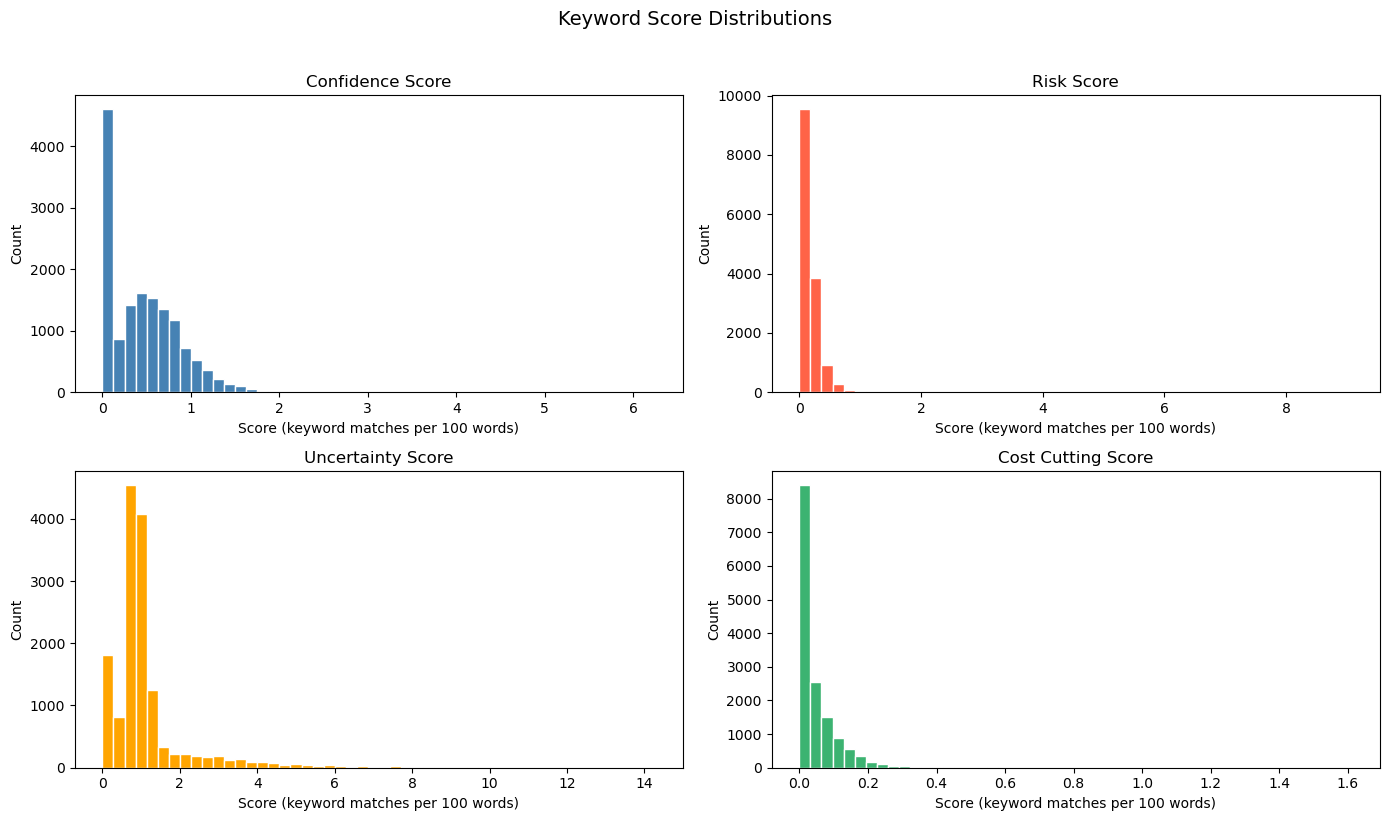

Saved: step7_keyword_distributions


In [21]:
# ── Distribution plots ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes      = axes.flatten()
colors    = ['steelblue', 'tomato', 'orange', 'mediumseagreen']

for i, col in enumerate(kw_cols):
    axes[i].hist(df_merged[col].dropna(), bins=50,
                 color=colors[i], edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Score (keyword matches per 100 words)')
    axes[i].set_ylabel('Count')

plt.suptitle('Keyword Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Outputs/sentiment_extraction/validation/step7_keyword_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step7_keyword_distributions")

In [22]:
# ── Spot checks ───────────────────────────────────────────────────────────────
for col in ['confidence_score', 'cost_cutting_score', 'risk_score']:
    print(f"\nTop 3 by {col}:")
    top = df_merged.nlargest(3, col)[
        ['ticker', 'earnings_date', col, 'net_sentiment', 'label_5d']
    ]
    print(top.to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
df_merged.to_csv('Outputs/sentiment_extraction/sentiment_merged_step7.csv', index=False)
print(f"\nSaved: sentiment_merged_step7.csv")
print(f"Shape: {df_merged.shape}")
print(f"\nAll columns in df_merged:")
for col in df_merged.columns:
    print(f"  {col}")


Top 3 by confidence_score:
      ticker earnings_date  confidence_score  net_sentiment  label_5d
7829     SXI    2021-02-05          6.250000       0.680785       1.0
11904    WCN    2021-10-29          5.031447       0.935105       0.0
13713    SXI    2021-11-05          3.703704       0.122489       1.0

Top 3 by cost_cutting_score:
     ticker earnings_date  cost_cutting_score  net_sentiment  label_5d
3595    LNT    2020-08-07            1.612903       0.049685       0.0
2257    MRK    2021-04-29            1.219512      -0.022300       1.0
9409    MRK    2021-07-29            1.000000      -0.034215       0.0

Top 3 by risk_score:
      ticker earnings_date  risk_score  net_sentiment  label_5d
1206     COO    2021-12-02    9.090909       0.015763       1.0
11952    COO    2022-03-03    9.090909       0.015763       0.0
5639     COO    2021-06-03    7.692308       0.049622       0.0

Saved: sentiment_merged_step7.csv
Shape: (14738, 37)

All columns in df_merged:
  ticker
  earnings

**Step 8 - Compute Additional Derived Features**

In [23]:
# Derives 4 features on top of the base FinBERT scores:
# 1. sentiment_volatility  — already computed in Step 4 (std of chunk scores)
# 2. mgmt_sentiment        — already computed in Step 6
# 3. qa_sentiment          — already computed in Step 6
# 4. sentiment_surprise    — quarter-over-quarter change in net_sentiment

import os
import matplotlib.pyplot as plt

os.makedirs('Outputs/sentiment_extraction', exist_ok=True)
os.makedirs('Outputs/sentiment_extraction/validation', exist_ok=True)

CHECKPOINT_EVERY = 500

print("Computing derived features...")
print(f"Input shape: {df_merged.shape}")

# ── Check features already available from earlier steps ──────────────────────
already_available = [
    'sentiment_volatility',
    'mgmt_sentiment',
    'qa_sentiment',
]

print("\nFeatures already computed in earlier steps:")
for col in already_available:
    if col in df_merged.columns:
        non_null = df_merged[col].notna().sum()
        print(f"  ✓ {col}: {non_null} non-null rows ({non_null/len(df_merged)*100:.1f}% coverage)")
    else:
        print(f"  ✗ {col}: MISSING — check Steps 4 and 6")

Computing derived features...
Input shape: (14738, 37)

Features already computed in earlier steps:
  ✓ sentiment_volatility: 14738 non-null rows (100.0% coverage)
  ✓ mgmt_sentiment: 14738 non-null rows (100.0% coverage)
  ✓ qa_sentiment: 14395 non-null rows (97.7% coverage)


In [24]:
# ── Feature 4: Sentiment Surprise (quarter-over-quarter change) ───────────────
print("Computing sentiment_surprise (QoQ change in net_sentiment)...")

# Convert earnings_date to datetime before sorting
df_merged['earnings_date'] = pd.to_datetime(
    df_merged['earnings_date'],
    errors='coerce'
)

# Sort by ticker and date to avoid look-ahead bias
df_merged = df_merged.sort_values(
    ['ticker', 'earnings_date']
).reset_index(drop=True)

# Compute previous quarter's net_sentiment per ticker
df_merged['prev_net_sentiment'] = (
    df_merged.groupby('ticker')['net_sentiment'].shift(1)
)

# Compute sentiment surprise: measure how much management's tone changed compared to the previous earnings call
df_merged['sentiment_surprise'] = (
    df_merged['net_sentiment'] - df_merged['prev_net_sentiment']
)

n_surprise      = df_merged['sentiment_surprise'].notna().sum()
n_first_quarter = df_merged['prev_net_sentiment'].isna().sum()

print(f"\nSentiment surprise computed:")
print(f"  Rows with surprise value:                {n_surprise}")
print(f"  Rows without (first quarter per ticker): {n_first_quarter}")
print(f"  Coverage: {n_surprise/len(df_merged)*100:.1f}%")
print(f"\nSentiment surprise distribution:")
print(df_merged['sentiment_surprise'].describe().round(4))

# Spot check
sample_ticker = df_merged['ticker'].value_counts().index[0]
sample = df_merged[df_merged['ticker'] == sample_ticker][
    ['ticker', 'earnings_date', 'q', 'net_sentiment',
     'prev_net_sentiment', 'sentiment_surprise']
].head(6)
print(f"\nSpot check — {sample_ticker}:")
print(sample.to_string())

Computing sentiment_surprise (QoQ change in net_sentiment)...

Sentiment surprise computed:
  Rows with surprise value:                12660
  Rows without (first quarter per ticker): 2078
  Coverage: 85.9%

Sentiment surprise distribution:
count    12660.0000
mean         0.0061
std          0.1330
min         -0.9878
25%         -0.0416
50%          0.0000
75%          0.0559
max          0.8571
Name: sentiment_surprise, dtype: float64

Spot check — AAPL:
   ticker earnings_date        q  net_sentiment  prev_net_sentiment  sentiment_surprise
36   AAPL    2019-07-30  2019-Q3       0.389557                 NaN                 NaN
37   AAPL    2020-01-28  2020-Q1       0.318690            0.389557           -0.070867
38   AAPL    2020-01-28  2020-Q1       0.318690            0.318690            0.000000
39   AAPL    2020-01-28  2020-Q1       0.318690            0.318690            0.000000
40   AAPL    2020-01-28  2020-Q1       0.318690            0.318690            0.000000
41   AAPL 

In [25]:
# ── Check for duplicate ticker + earnings_date rows ───────────────────────────
dupes = df_merged.groupby(['ticker', 'earnings_date']).size()
dupes = dupes[dupes > 1]
print(f"Ticker+date combinations with duplicates: {len(dupes)}")
print(f"\nTop 10 duplicated combinations:")
print(dupes.sort_values(ascending=False).head(10))

# Check AAPL specifically
aapl = df_merged[df_merged['ticker'] == 'AAPL'][
    ['ticker', 'earnings_date', 'q', 'net_sentiment', 'sentiment_surprise']
]
print(f"\nAll AAPL rows:")
print(aapl.to_string())

Ticker+date combinations with duplicates: 640

Top 10 duplicated combinations:
ticker  earnings_date
TSLA    2020-07-22       32
DIS     2020-08-04       25
AAPL    2020-04-30       25
AMZN    2020-07-30       25
AAPL    2020-01-28       21
GOOGL   2020-04-28       15
        2021-07-27       14
        2021-02-02       10
CF      2020-05-07        8
PTC     2023-02-01        8
dtype: int64

All AAPL rows:
   ticker earnings_date        q  net_sentiment  sentiment_surprise
36   AAPL    2019-07-30  2019-Q3       0.389557                 NaN
37   AAPL    2020-01-28  2020-Q1       0.318690           -0.070867
38   AAPL    2020-01-28  2020-Q1       0.318690            0.000000
39   AAPL    2020-01-28  2020-Q1       0.318690            0.000000
40   AAPL    2020-01-28  2020-Q1       0.318690            0.000000
41   AAPL    2020-01-28  2020-Q1       0.318690            0.000000
42   AAPL    2020-01-28  2020-Q1       0.318690            0.000000
43   AAPL    2020-01-28  2020-Q1       0.31869

In [26]:
# ── Fix: deduplicate before computing sentiment_surprise ──────────────────────
print(f"Rows before dedup: {len(df_merged)}")

df_merged = df_merged.drop_duplicates(
    subset=['ticker', 'earnings_date', 'q'],
    keep='first'
).reset_index(drop=True)

print(f"Rows after dedup:  {len(df_merged)}")
print(f"Duplicates removed: {14738 - len(df_merged)}")

# ── Re-run sentiment surprise with clean data ─────────────────────────────────
df_merged['earnings_date'] = pd.to_datetime(
    df_merged['earnings_date'], errors='coerce'
)

df_merged = df_merged.sort_values(
    ['ticker', 'earnings_date']
).reset_index(drop=True)

df_merged['prev_net_sentiment'] = (
    df_merged.groupby('ticker')['net_sentiment'].shift(1)
)

df_merged['sentiment_surprise'] = (
    df_merged['net_sentiment'] - df_merged['prev_net_sentiment']
)

n_surprise      = df_merged['sentiment_surprise'].notna().sum()
n_first_quarter = df_merged['prev_net_sentiment'].isna().sum()

print(f"\nSentiment surprise recomputed:")
print(f"  Rows with surprise value:                {n_surprise}")
print(f"  Rows without (first quarter per ticker): {n_first_quarter}")
print(f"  Coverage: {n_surprise/len(df_merged)*100:.1f}%")

# ── Look-ahead bias check ─────────────────────────────────────────────────────
first_rows          = df_merged.groupby('ticker', as_index=False).nth(0)
first_with_surprise = first_rows['sentiment_surprise'].notna().sum()
if first_with_surprise == 0:
    print("\n✓ Look-ahead bias check PASSED")
else:
    print(f"\n✗ Look-ahead bias check FAILED — {first_with_surprise} tickers affected")

# ── Verify AAPL is now clean ──────────────────────────────────────────────────
aapl = df_merged[df_merged['ticker'] == 'AAPL'][
    ['ticker', 'earnings_date', 'q', 'net_sentiment', 'sentiment_surprise']
]
print(f"\nAAPL after dedup:")
print(aapl.to_string())

df_merged = df_merged.drop(columns=['prev_net_sentiment'])

Rows before dedup: 14738
Rows after dedup:  13803
Duplicates removed: 935

Sentiment surprise recomputed:
  Rows with surprise value:                11725
  Rows without (first quarter per ticker): 2078
  Coverage: 84.9%

✓ Look-ahead bias check PASSED

AAPL after dedup:
   ticker earnings_date        q  net_sentiment  sentiment_surprise
33   AAPL    2019-07-30  2019-Q3       0.389557                 NaN
34   AAPL    2020-01-28  2020-Q1       0.318690           -0.070867
35   AAPL    2020-04-30  2020-Q2       0.201287           -0.117403
36   AAPL    2020-07-30  2020-Q3       0.414933            0.213646
37   AAPL    2020-10-29  2020-Q4       0.028859           -0.386074
38   AAPL    2021-01-27  2021-Q1       0.025128           -0.003731
39   AAPL    2021-04-28  2021-Q2       0.040284            0.015155
40   AAPL    2021-07-27  2021-Q3       0.022506           -0.017778
41   AAPL    2021-10-28  2021-Q4       0.035994            0.013489
42   AAPL    2022-01-27  2022-Q1       0.039560 

In [27]:
# ── Drop helper column if it still exists ────────────────────────────────────
if 'prev_net_sentiment' in df_merged.columns:
    df_merged = df_merged.drop(columns=['prev_net_sentiment'])

# ── Summary of all derived features ───────────────────────────────────────────
derived_cols = [
    'sentiment_volatility',
    'mgmt_sentiment',
    'qa_sentiment',
    'sentiment_surprise'
]

print("Derived features summary:")
print(df_merged[derived_cols].describe().round(4).to_string())

print("\nNull counts:")
for col in derived_cols:
    null_count = df_merged[col].isna().sum()
    coverage   = (len(df_merged) - null_count) / len(df_merged) * 100
    print(f"  {col:30s}: {null_count} nulls ({coverage:.1f}% coverage)")

Derived features summary:
       sentiment_volatility  mgmt_sentiment  qa_sentiment  sentiment_surprise
count            13803.0000      13803.0000    13482.0000          11725.0000
mean                 0.2510          0.3444        0.1040              0.0066
std                  0.1854          0.2230        0.0956              0.1382
min                  0.0000         -0.9294       -0.8396             -0.9878
25%                  0.0000          0.2163        0.0553             -0.0497
50%                  0.3135          0.3554        0.0964              0.0015
75%                  0.3857          0.4910        0.1508              0.0639
max                  0.8481          0.9263        0.7142              0.8571

Null counts:
  sentiment_volatility          : 0 nulls (100.0% coverage)
  mgmt_sentiment                : 0 nulls (100.0% coverage)
  qa_sentiment                  : 321 nulls (97.7% coverage)
  sentiment_surprise            : 2078 nulls (84.9% coverage)


In [28]:
# ── Correlation analysis ──────────────────────────────────────────────────────

all_sentiment_cols = [
    'net_sentiment', 'mgmt_sentiment', 'qa_sentiment',
    'sentiment_volatility', 'sentiment_surprise'
]

for label_col in ['label_5d', 'label_10d']:
    print(f"\nCorrelation with {label_col}:")

    # Skip if label column not present
    if label_col not in df_merged.columns:
        print(f"  {label_col} missing — skipping")
        continue

    for col in all_sentiment_cols:
        if col in df_merged.columns:
            corr = df_merged[col].corr(df_merged[label_col])
            print(f"  {col:30s} vs {label_col}: {corr:+.4f}")


Correlation with label_5d:
  net_sentiment                  vs label_5d: +0.0090
  mgmt_sentiment                 vs label_5d: +0.0264
  qa_sentiment                   vs label_5d: +0.0404
  sentiment_volatility           vs label_5d: +0.0079
  sentiment_surprise             vs label_5d: +0.0415

Correlation with label_10d:
  net_sentiment                  vs label_10d: -0.0113
  mgmt_sentiment                 vs label_10d: -0.0121
  qa_sentiment                   vs label_10d: +0.0290
  sentiment_volatility           vs label_10d: +0.0134
  sentiment_surprise             vs label_10d: +0.0443


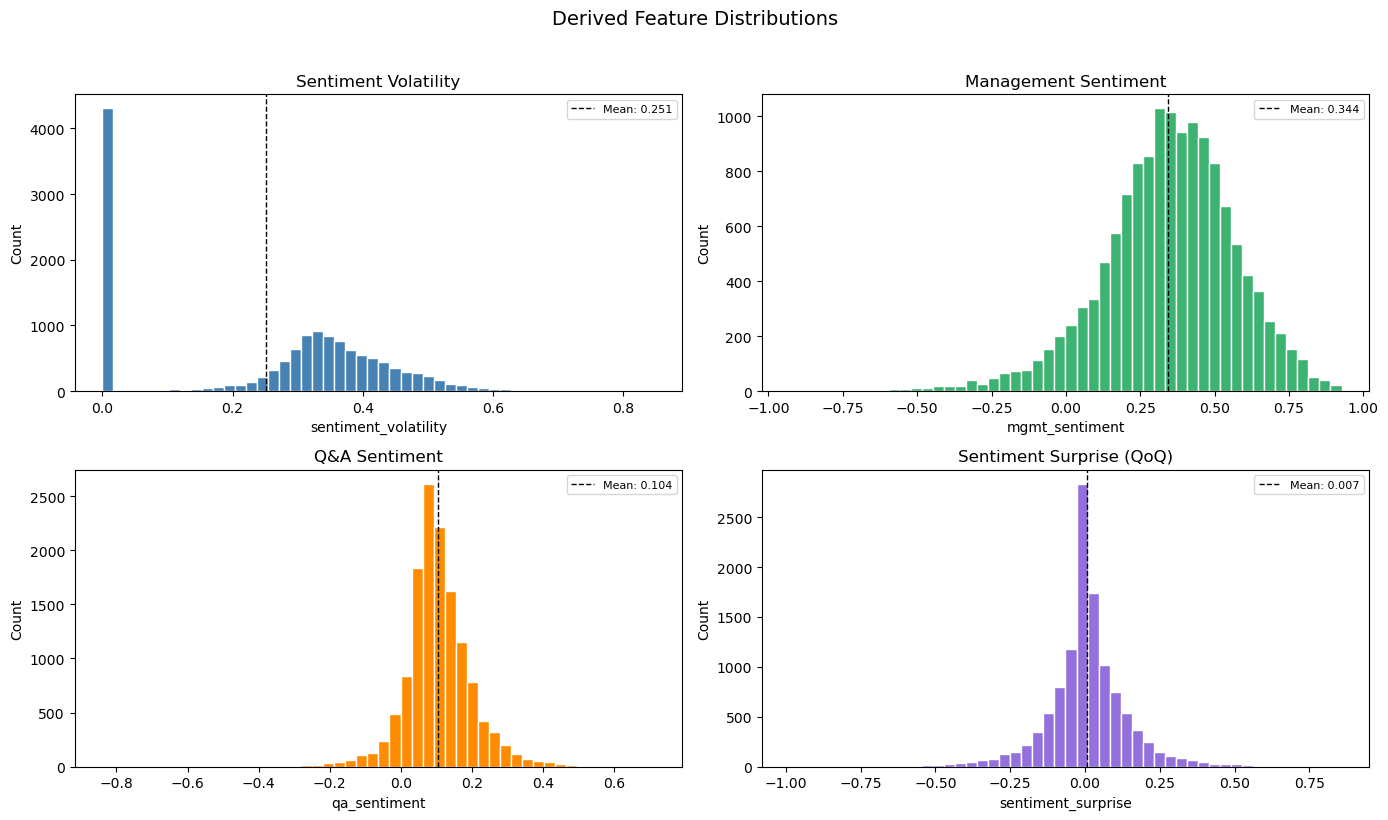

Saved: step8_derived_distributions.png


In [29]:
# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes      = axes.flatten()

plot_cols = ['sentiment_volatility', 'mgmt_sentiment',
             'qa_sentiment',         'sentiment_surprise']
colors    = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']
titles    = ['Sentiment Volatility', 'Management Sentiment',
             'Q&A Sentiment',        'Sentiment Surprise (QoQ)']

for i, (col, color, title) in enumerate(zip(plot_cols, colors, titles)):
    if col in df_merged.columns:
        data = df_merged[col].dropna()
        axes[i].hist(data, bins=50, color=color, edgecolor='white')
        axes[i].set_title(title)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].axvline(data.mean(), color='black',
                        linestyle='--', linewidth=1,
                        label=f'Mean: {data.mean():.3f}')
        axes[i].legend(fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'{col}\nNOT FOUND',
                     ha='center', va='center',
                     transform=axes[i].transAxes)

plt.suptitle('Derived Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs('Outputs/sentiment_extraction/validation', exist_ok=True)
plt.savefig('Outputs/sentiment_extraction/validation/step8_derived_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step8_derived_distributions.png")

In [30]:
# ── Save updated df_merged ────────────────────────────────────────────────────
df_merged.to_csv(
    'Outputs/sentiment_extraction/sentiment_merged_step8.csv',
    index=False
)

print(f"\nSaved: sentiment_merged_step8.csv")
print(f"Shape: {df_merged.shape}")
print(f"\nAll columns in df_merged:")
for col in df_merged.columns:
    print(f"  {col}")


Saved: sentiment_merged_step8.csv
Shape: (13803, 38)

All columns in df_merged:
  ticker
  earnings_date
  q
  earnings_date_is_approx
  transcript
  transcript_clean
  speaker_parse_success
  return_5d
  return_10d
  return_20d
  label_5d
  label_10d
  label_20d
  exec_text
  analyst_text
  positive_ratio
  negative_ratio
  neutral_ratio
  net_sentiment
  sentiment_volatility
  n_chunks
  mgmt_positive_ratio
  mgmt_negative_ratio
  mgmt_neutral_ratio
  mgmt_sentiment
  mgmt_sentiment_volatility
  mgmt_n_chunks
  qa_positive_ratio
  qa_negative_ratio
  qa_neutral_ratio
  qa_sentiment
  qa_sentiment_volatility
  qa_n_chunks
  confidence_score
  risk_score
  uncertainty_score
  cost_cutting_score
  sentiment_surprise


**Step 9: Assemble Final Sentiment Feature File**

In [31]:
# Combines all scores computed in Steps 4-8 into one clean handoff file
# Generate the input for Phase 3: sentiment_features.csv

import os

SENTIMENT_DIR  = 'Outputs/sentiment_extraction'
VALIDATION_DIR = 'Outputs/sentiment_extraction/validation'
SENTIMENT_FINAL = os.path.join(SENTIMENT_DIR, 'sentiment_features.csv')

os.makedirs(SENTIMENT_DIR,  exist_ok=True)
os.makedirs(VALIDATION_DIR, exist_ok=True)

print("Assembling final sentiment feature file...")
print(f"Input shape: {df_merged.shape}")

Assembling final sentiment feature file...
Input shape: (13803, 38)


In [32]:
# ── Define all expected columns ───────────────────────────────────────────────
COLS_IDENTITY = ['ticker', 'earnings_date', 'q']

COLS_FINBERT_FULL = [
    'net_sentiment', 'positive_ratio', 'negative_ratio',
    'neutral_ratio', 'sentiment_volatility', 'n_chunks',
]

COLS_FINBERT_SPLIT = [
    'mgmt_sentiment', 'mgmt_positive_ratio', 'mgmt_negative_ratio',
    'mgmt_neutral_ratio', 'mgmt_sentiment_volatility', 'mgmt_n_chunks',
    'qa_sentiment', 'qa_positive_ratio', 'qa_negative_ratio',
    'qa_neutral_ratio', 'qa_sentiment_volatility', 'qa_n_chunks',
]

COLS_KEYWORD = [
    'confidence_score', 'risk_score',
    'uncertainty_score', 'cost_cutting_score',
]

COLS_DERIVED = ['sentiment_surprise']

COLS_LABELS = [
    'label_5d', 'label_10d', 'label_20d',
    'return_5d', 'return_10d', 'return_20d',
]

ALL_COLS = (
    COLS_IDENTITY + COLS_FINBERT_FULL + COLS_FINBERT_SPLIT +
    COLS_KEYWORD + COLS_DERIVED + COLS_LABELS
)

print(f"Expected columns: {len(ALL_COLS)}")
for col in ALL_COLS:
    status = '✓' if col in df_merged.columns else '✗ MISSING'
    print(f"  {status}  {col}")

# ── Select only existing columns ──────────────────────────────────────────────
existing_cols = [c for c in ALL_COLS if c in df_merged.columns]
missing_cols  = [c for c in ALL_COLS if c not in df_merged.columns]

print(f"\nColumns available: {len(existing_cols)}")
print(f"Columns missing:   {len(missing_cols)}")

if missing_cols:
    print(f"\nMissing columns (excluded from final file):")
    for col in missing_cols:
        print(f"  ✗ {col}")
    print("\nNote: missing split columns are expected if exec_text/analyst_text")
    print("were not available for the Motley Fool pkl dataset.")

sentiment_features = df_merged[existing_cols].copy()
print(f"\nFinal feature file shape: {sentiment_features.shape}")

Expected columns: 32
  ✓  ticker
  ✓  earnings_date
  ✓  q
  ✓  net_sentiment
  ✓  positive_ratio
  ✓  negative_ratio
  ✓  neutral_ratio
  ✓  sentiment_volatility
  ✓  n_chunks
  ✓  mgmt_sentiment
  ✓  mgmt_positive_ratio
  ✓  mgmt_negative_ratio
  ✓  mgmt_neutral_ratio
  ✓  mgmt_sentiment_volatility
  ✓  mgmt_n_chunks
  ✓  qa_sentiment
  ✓  qa_positive_ratio
  ✓  qa_negative_ratio
  ✓  qa_neutral_ratio
  ✓  qa_sentiment_volatility
  ✓  qa_n_chunks
  ✓  confidence_score
  ✓  risk_score
  ✓  uncertainty_score
  ✓  cost_cutting_score
  ✓  sentiment_surprise
  ✓  label_5d
  ✓  label_10d
  ✓  label_20d
  ✓  return_5d
  ✓  return_10d
  ✓  return_20d

Columns available: 32
Columns missing:   0

Final feature file shape: (13803, 32)


In [33]:
# ── Data quality checks before saving ─────────────────────────────────────────
print("Data quality checks:")

# Convert earnings_date to datetime before reporting date range
sentiment_features['earnings_date'] = pd.to_datetime(
    sentiment_features['earnings_date'],
    errors='coerce'
)

# Use ticker + earnings_date + q as dedup key
subset_cols = ['ticker', 'earnings_date', 'q']
dupes = sentiment_features.duplicated(subset=subset_cols).sum()

print(f"\n  Duplicate (ticker, earnings_date, q) rows: {dupes}")
if dupes > 0:
    print("  ✗ WARNING — duplicates found, dropping...")
    sentiment_features = sentiment_features.drop_duplicates(subset=subset_cols)
    print(f"  Shape after dedup: {sentiment_features.shape}")
else:
    print("  ✓ No duplicates")

# Coverage per feature
print(f"\n  Coverage per feature (non-null rows):")
for col in existing_cols:
    non_null = sentiment_features[col].notna().sum()
    pct      = non_null / len(sentiment_features) * 100
    flag     = '  ← LOW COVERAGE' if pct < 80 else ''
    print(f"    {col:35s}: {non_null:6d} / {len(sentiment_features)} ({pct:.1f}%){flag}")

# Label balance
if 'label_5d' in sentiment_features.columns:
    print(f"\n  Label distribution (label_5d):")
    print(sentiment_features['label_5d'].value_counts().to_string())

# Date range
print(f"\n  Date range: "
      f"{sentiment_features['earnings_date'].min()} to "
      f"{sentiment_features['earnings_date'].max()}")
print(f"  Unique tickers: {sentiment_features['ticker'].nunique()}")
print(f"  Total rows:     {len(sentiment_features)}")

Data quality checks:

  Duplicate (ticker, earnings_date, q) rows: 0
  ✓ No duplicates

  Coverage per feature (non-null rows):
    ticker                             :  13803 / 13803 (100.0%)
    earnings_date                      :  13803 / 13803 (100.0%)
    q                                  :  13803 / 13803 (100.0%)
    net_sentiment                      :  13803 / 13803 (100.0%)
    positive_ratio                     :  13803 / 13803 (100.0%)
    negative_ratio                     :  13803 / 13803 (100.0%)
    neutral_ratio                      :  13803 / 13803 (100.0%)
    sentiment_volatility               :  13803 / 13803 (100.0%)
    n_chunks                           :  13803 / 13803 (100.0%)
    mgmt_sentiment                     :  13803 / 13803 (100.0%)
    mgmt_positive_ratio                :  13803 / 13803 (100.0%)
    mgmt_negative_ratio                :  13803 / 13803 (100.0%)
    mgmt_neutral_ratio                 :  13803 / 13803 (100.0%)
    mgmt_sentiment_volatili

In [34]:
# ── Correlation summary ───────────────────────────────────────────────────────
feature_cols = (
    COLS_FINBERT_FULL +
    [c for c in COLS_FINBERT_SPLIT if c in sentiment_features.columns] +
    COLS_KEYWORD +
    COLS_DERIVED
)

# Guard against NaN correlation crashing the bar chart
if 'label_5d' in sentiment_features.columns:
    corr_summary = []

    for col in feature_cols:
        if col in sentiment_features.columns:
            corr = sentiment_features[col].corr(
                sentiment_features['label_5d']
            )
            corr_summary.append((col, corr))

    # Sort — push NaN correlations to the bottom
    corr_summary.sort(
        key=lambda x: abs(x[1]) if pd.notna(x[1]) else -1,
        reverse=True
    )

    print(f"\n  {'Feature':<35} {'Corr with label_5d':>20}")
    print(f"  {'-'*35} {'-'*20}")

    for col, corr in corr_summary:
        if pd.isna(corr):
            print(f"  {col:<35} {'NaN':>20}")
        else:
            bar       = '█' * int(abs(corr) * 50)
            direction = '+' if corr >= 0 else '-'
            print(f"  {col:<35} {corr:>+.4f}  {direction}{bar}")
else:
    print("  label_5d missing — skipping correlation summary")


  Feature                               Corr with label_5d
  ----------------------------------- --------------------
  qa_positive_ratio                   +0.0463  +██
  sentiment_surprise                  +0.0415  +██
  qa_sentiment                        +0.0404  +██
  mgmt_positive_ratio                 +0.0369  +█
  qa_n_chunks                         +0.0367  +█
  mgmt_neutral_ratio                  -0.0350  -█
  qa_neutral_ratio                    -0.0348  -█
  qa_sentiment_volatility             +0.0327  +█
  mgmt_sentiment                      +0.0264  +█
  confidence_score                    +0.0172  +
  risk_score                          +0.0160  +
  n_chunks                            +0.0145  +
  mgmt_n_chunks                       -0.0126  -
  positive_ratio                      +0.0099  +
  net_sentiment                       +0.0090  +
  neutral_ratio                       -0.0089  -
  sentiment_volatility                +0.0079  +
  qa_negative_ratio                 

In [35]:
# ── Save final sentiment features file ────────────────────────────────────────
sentiment_features.to_csv(SENTIMENT_FINAL, index=False)

print("=" * 60)
print("PHASE 2 COMPLETE")
print("=" * 60)
print(f"Final file:     {SENTIMENT_FINAL}")
print(f"Shape:          {sentiment_features.shape}")
print(f"Tickers:        {sentiment_features['ticker'].nunique()}")
print(f"Date range:     {sentiment_features['earnings_date'].min()} "
      f"to {sentiment_features['earnings_date'].max()}")
print(f"\nFeature groups:")
print(f"  FinBERT full transcript: "
      f"{len([c for c in COLS_FINBERT_FULL if c in sentiment_features.columns])} features")
print(f"  FinBERT mgmt/QA split:   "
      f"{len([c for c in COLS_FINBERT_SPLIT if c in sentiment_features.columns])} features")
print(f"  Keyword-based:           "
      f"{len([c for c in COLS_KEYWORD if c in sentiment_features.columns])} features")
print(f"  Derived:                 "
      f"{len([c for c in COLS_DERIVED if c in sentiment_features.columns])} features")
print(f"  Labels/returns:          "
      f"{len([c for c in COLS_LABELS if c in sentiment_features.columns])} columns")
print(f"\nFiles in {SENTIMENT_DIR}/:")

for f in sorted(os.listdir(SENTIMENT_DIR)):
    fpath = os.path.join(SENTIMENT_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {f:<45} {size_mb:.1f} MB")

print(f"\nHand-off to Phase 3: sentiment_features.csv.")
print("=" * 60)

PHASE 2 COMPLETE
Final file:     Outputs/sentiment_extraction/sentiment_features.csv
Shape:          (13803, 32)
Tickers:        2078
Date range:     2017-10-01 00:00:00 to 2023-02-23 00:00:00

Feature groups:
  FinBERT full transcript: 6 features
  FinBERT mgmt/QA split:   12 features
  Keyword-based:           4 features
  Derived:                 1 features
  Labels/returns:          6 columns

Files in Outputs/sentiment_extraction/:
  mgmt_scores_raw.csv                           1.7 MB
  qa_scores_raw.csv                             1.7 MB
  sentiment_features.csv                        5.6 MB
  sentiment_merged_step6.csv                    1767.3 MB
  sentiment_merged_step7.csv                    1767.6 MB
  sentiment_merged_step8.csv                    1650.5 MB
  sentiment_scores_raw.csv                      1.7 MB

Hand-off to Phase 3: sentiment_features.csv.


**Phase 2 Complete — Sentiment Extraction Results and Final Dataset Summary:**
- FinBERT sentiment scoring was completed on all transcripts using a chunking strategy with 512-token windows and 50-token overlap, with mean aggregation across chunks to produce document-level scores. The full inference run of 14,738 transcripts took 132.4 minutes on a T4 GPU via Google Colab, producing `sentiment_scores_raw.csv` with 14,738 rows and zero null values.
- A new speaker parser was developed specifically for the Motley Fool transcript format, achieving a parse rate of 99.8% for `exec_text` (management prepared remarks) and 97.6% for `analyst_text` (Q&A section). Management and Q&A sentiment were then scored separately on Kaggle (T4 x2 GPU) due to Colab GPU quota exhaustion, producing `mgmt_scores_raw.csv` (14,738 rows, 0 nulls) and `qa_scores_raw.csv` (14,738 rows, 343 nulls for transcripts with no Q&A section).
- 935 duplicate earnings call entries were identified and removed from the original Motley Fool pkl, reducing the dataset from 14,738 to **13,803 clean rows** across **2,078 unique tickers**.
- Four keyword-based scores (confidence, risk, uncertainty, cost-cutting) were computed for all 13,803 rows in under 2 minutes on CPU, and sentiment surprise (quarter-over-quarter change in net sentiment) was derived for 11,725 rows (84.9% coverage), with 2,078 NaN rows correctly corresponding to each ticker's first earnings call.
- Correlation analysis against the 5-day return label reveals that Q&A-based features are the strongest predictors — `qa_positive_ratio` (+0.046), `sentiment_surprise` (+0.042), and `qa_sentiment` (+0.040) — consistently outperforming full-transcript features such as `net_sentiment` (+0.009), validating the value of speaker-level separation.
- The final handoff file `sentiment_features.csv` contains **13,803 rows, 2,078 tickers, and 32 columns** spanning 6 FinBERT full-transcript features, 12 FinBERT mgmt/QA split features, 4 keyword scores, 1 derived feature, and 6 label/return columns, ready for Phase 3 feature engineering and ML training.